In [1]:
import pandas as pd
import re
import os
import time
from openai import OpenAI

# Data Preparation

In [4]:
df = pd.read_csv("hf://datasets/nbertagnolli/counsel-chat/20220401_counsel_chat.csv")

In [6]:
df.head(1)

,questionID,questionTitle,questionText,questionLink,topic,therapistInfo,therapistURL,answerText,upvotes,views
0,0,Do I have too many issues for counseling?,I have so many issues to address. I have a his...,https://counselchat.com/questions/do-i-have-to...,depression,Jennifer MolinariHypnotherapist & Licensed Cou...,https://counselchat.com/therapists/jennifer-mo...,It is very common for people to have multiple ...,3,1971


## Checking for missing entries

In [9]:
df.isna().sum()

questionID         0
questionTitle      0
questionText     139
questionLink       0
topic              0
therapistInfo      0
therapistURL       0
answerText        26
upvotes            0
views              0
dtype: int64

In [11]:
df = df.dropna(subset=["questionText", "answerText"])

In [13]:
df.isna().sum()

questionID       0
questionTitle    0
questionText     0
questionLink     0
topic            0
therapistInfo    0
therapistURL     0
answerText       0
upvotes          0
views            0
dtype: int64

The missing entries are removed as there is plenty of data to work with.

# Merging Title and Text

In the dataset, it is a common occurrence that the question is in the title of the post, and the post itself only provides further explanation regarding the question. Therefore, the title is appended to the front of the post to ensure the LLM and the licensed therapist receive identical information.

In [18]:
def merge_title_text(title, text):
    title = title.strip()
    if re.search(r'[.!?]$', title):
        return f"{title} {text}"
    else:
        return f"{title}. {text}"

df["questionText"] = df.apply(
    lambda row: merge_title_text(row["questionTitle"], row["questionText"]),
    axis=1
)

In [20]:
df = df[['questionText','answerText']]

In [22]:
df.head()

,questionText,answerText
0,Do I have too many issues for counseling? I ha...,It is very common for people to have multiple ...
1,Do I have too many issues for counseling? I ha...,"I've never heard of someone having ""too many i..."
2,Do I have too many issues for counseling? I ha...,Absolutely not. I strongly recommending worki...
3,Do I have too many issues for counseling? I ha...,Let me start by saying there are never too man...
4,Do I have too many issues for counseling? I ha...,I just want to acknowledge you for the courage...


## Duplicates

There are various duplicate entries in the data. For every unique response, the question re-occurs in the questionText column. However, this is not a problem. What could be a potential problem is the appearance of duplicate entries in the therapists' answers. It is critical that these entries are evaluated to ensure there are no incorrectly copied responses on different questions that do not relate to the question, as this could lead to large differences in substantive content between the therapist's and the LLM's response.

In [26]:
#Displays all duplicate entries in answers, and their related questions
duplicates = df[df.duplicated(subset=['answerText'], keep=False)]
result = duplicates[['questionText', 'answerText']].sort_values(by='answerText')

print(result)

                                           questionText  \
1317  How can I cope with the loss of someone I love...   
1433  How can I control myself and my anger? I snap ...   
543   I have difficulty with communication. I am a r...   
2055  Why is it hard for me to express myself? I don...   
1296  My past is holding me back from my future. How...   
1310  How do I cope with posttraumatic stress disord...   
1316  How can I cope with the loss of someone I love...   
1334  PTSD is impacting my whole life. I have PTSD. ...   
1587  How can I not be afraid of commitment? I've pr...   
2309  How can I concentrate? I can't understand what...   
1828  What can I do when my family doesn't accept my...   
1854  What can I do about my family not accepting me...   
2517  How would I know if I have the right therapist...   
2727  How does someone approach a counselor? How doe...   
535   How can I make the voices stop? I don't rememb...   
2481  Why can't I stop these thoughts? I keep having... 

In [28]:
#A function to check for duplicates for convenience
def checkDupe(index):
    print(df['questionText'][index])
    print("")
    print(df['answerText'][index])
    return 

checkDupe(1433)

How can I control myself and my anger? I snap easy and push people away. I need help before I push my boyfriend away.

Death of someone with whom we had fond involvement, is sad.   Accepting that a person is permanently gone from this earth, is unsettling and can feel painful.That you had no current contact with this person doesn't exclude the meaning or feelings from within your relationship with this person.     Relationships don't require a time measurement in order to affect us.   Your question acknowledges the process of adjusting to life without the chance to see or hear from this person again.It is normal to grieve so be gentle and not critical of yourself when you feel yourself missing this person.


### Misalignment
This question does not at all mention the death of a loved one, whereas the answer does. This answer was likely incorrectly copied from the question at index 1317. Therefore, this row is dropped.

In [31]:
#Drop row 1433 as its response does not align with the question
df = df.drop(index=1433)

In [33]:
checkDupe(2055)

Why is it hard for me to express myself? I don't know how to tell someone how I feel about them. How can I get better at expressing how I feel?

I wanted to share these two short books (see below). You could also look into working on your throat chakra which deals with speaking your truth, self-expression,  being heard.  Communication Crunch High Impact Communication


In [35]:
checkDupe(1296)

My past is holding me back from my future. How can I get my life back? There are issues from my past that have me very heavily burdened in my heart. I've been torn for so many years and I need help so I can move on with my life.
   I experienced trauma when I was 8 years old and I did come out about it until I was 40.
   Now I know this is what's holding me back on my happiness. I've met a very loving and caring man but because I'm holding on to these things from my past I’m pushing him away.
   How can I get my life back?

Often people with extensive trauma have difficulty talking about it. This lessens the impact of traditional talk therapy and there benefits. There is a helpful therapy called EMDR that is limited in the amount of talking and also has quick benefits for the reduction of symptoms. For those who are in great distress you can also complete EMDR therapy every day if you would like/have the means. This can quicken the recovery time from these distressing life events.


In [37]:
checkDupe(1310)

How do I cope with posttraumatic stress disorder and its triggers? I am a survivor of multiple sexual abuse/rape experiences. Triggers are having an effect on my daily life and my sexual relationship with my partner. I'm trying to learn to cope with them.

Often people with extensive trauma have difficulty talking about it. This lessens the impact of traditional talk therapy and there benefits. There is a helpful therapy called EMDR that is limited in the amount of talking and also has quick benefits for the reduction of symptoms. For those who are in great distress you can also complete EMDR therapy every day if you would like/have the means. This can quicken the recovery time from these distressing life events.


In [39]:
checkDupe(1316)

How can I cope with the loss of someone I love? My good childhood friend died suddenly as a teenager. I haven't seen him in four years and haven't talked to him in months yet somehow this hurts me more than I could ever imagine. It's been about three months since his passing, and I'm still not sure how to cope with this.

Often people with extensive trauma have difficulty talking about it. This lessens the impact of traditional talk therapy and there benefits. There is a helpful therapy called EMDR that is limited in the amount of talking and also has quick benefits for the reduction of symptoms. For those who are in great distress you can also complete EMDR therapy every day if you would like/have the means. This can quicken the recovery time from these distressing life events.


In [41]:
checkDupe(1334)

PTSD is impacting my whole life. I have PTSD. The side effects are really bad and have impacts on sex, anger and my relationships. I even lost my job month ago.    How can I get my life back?

Often people with extensive trauma have difficulty talking about it. This lessens the impact of traditional talk therapy and there benefits. There is a helpful therapy called EMDR that is limited in the amount of talking and also has quick benefits for the reduction of symptoms. For those who are in great distress you can also complete EMDR therapy every day if you would like/have the means. This can quicken the recovery time from these distressing life events.


In [43]:
checkDupe(1587)

How can I not be afraid of commitment? I've pretty much been on my own since day one, I'm a middle child of five, and I can't seem to put my trust in anyone. It took me four years to finally open up a little to my best friend. Every time I realize that I have feelings for someone, I freak out and never talk to them again. I really want some help.

One way to concentrate is that if your mind starts to wonder then remind yourself to bring your attention back.Start with short time spans of expecting yourself to concentrate.  You'll more likely succeed with concentrating with small time spans than longer ones.Once you start seeing your success, this will motivate you to try increasing the length to expect yourself to concentrate.The task of self-reminding is the same, whether for long or short time periods.Also, before starting this exercise ask your medical doctor if the problem can be related to a physical health problem.If there is, then have the possibility ruled out that your difficul

### Misalignment
The question is about being scared of commitment, whereas the answer focuses on concentration issues. This was likely incorrectly copied from the question at index 2309 and will be dropped.

In [46]:
#Drop row 1587 as its response does not align with the question
df = df.drop(index=1587)

In [48]:
checkDupe(2309)

How can I concentrate? I can't understand what I pay attention to.

One way to concentrate is that if your mind starts to wonder then remind yourself to bring your attention back.Start with short time spans of expecting yourself to concentrate.  You'll more likely succeed with concentrating with small time spans than longer ones.Once you start seeing your success, this will motivate you to try increasing the length to expect yourself to concentrate.The task of self-reminding is the same, whether for long or short time periods.Also, before starting this exercise ask your medical doctor if the problem can be related to a physical health problem.If there is, then have the possibility ruled out that your difficulty concentrating comes from the mental ability to concentrate, and not some medical reason preventing this.Before someone can engage their psychological will there must be a clean medical body and mind with which to work.


In [50]:
checkDupe(1828)

What can I do when my family doesn't accept my sexuality? I'm a teenage gay girl, and I'm in love with a girl a few years older than me. She loves me too, but we're not physically together at the moment. I've been thinking about being transgender soon too, but my family doesn't accept me, so I honestly don't know what to do about that because I feel like I have to constantly hide the real me. It hurts so much to hide the real me. What can I do?

Sending you healing vibes as you endure their being unaccepting. I wanted to share this video about coming out Coming OutI know it is hard when those we love do not accept us as we are.  One thing to ask, is this something that you need their approval around?  Owning who you are regardless of what others say sometimes helps.  This may not be a part of your life you can share with them.  We all have areas we have strong beliefs. Ideally, they would accept you no matter what but that does not seem to be the case.  Deciding if this is a deal-break

In [52]:
checkDupe(1854)

What can I do about my family not accepting me as bisexual? After I told them, they yelled at me.

Sending you healing vibes as you endure their being unaccepting. I wanted to share this video about coming out Coming OutI know it is hard when those we love do not accept us as we are.  One thing to ask, is this something that you need their approval around?  Owning who you are regardless of what others say sometimes helps.  This may not be a part of your life you can share with them.  We all have areas we have strong beliefs. Ideally, they would accept you no matter what but that does not seem to be the case.  Deciding if this is a deal-breaker, or can you work around it, not sharing this part of your life, and understanding we cannot force people to embrace what they do not want to embrace.  You get to live your life as you see fit and be happy. You deserve joy and to live authentically!   If you are confident in your choice, choose your choice, own that, and set boundaries around it. 

In [54]:
checkDupe(2517)

How would I know if I have the right therapist? How do you know you have the right therapist for you?
 How would I know how to "train" my therapist to be able to give me what I need from treatment?

The therapeutic relationship is such an important aspect of the process toward healing. Feeling comfortable enough to be vulnerable is a good starting place. Understanding your own goals for therapy, outcomes you hope to get from it, and the approach you need from your therapist. Each therapist is unique and have their individual styles and theoretical orientations they align with. Open and honest communication regarding what you are hoping to get out of therapy and asking questions from the start of therapist to better understand if their theoretical approach will be helpful to you is a good starting place. Knowing and trusting yourself that if it is not a good fit that it is okay to seek therapy from another provider.


In [56]:
checkDupe(2727)

How does someone approach a counselor? How does a person start the counseling process?

The therapeutic relationship is such an important aspect of the process toward healing. Feeling comfortable enough to be vulnerable is a good starting place. Understanding your own goals for therapy, outcomes you hope to get from it, and the approach you need from your therapist. Each therapist is unique and have their individual styles and theoretical orientations they align with. Open and honest communication regarding what you are hoping to get out of therapy and asking questions from the start of therapist to better understand if their theoretical approach will be helpful to you is a good starting place. Knowing and trusting yourself that if it is not a good fit that it is okay to seek therapy from another provider.


In [58]:
checkDupe(535)

How can I make the voices stop? I don't remember when the voices in my head started, but I remember Hearing them when I was little.    I know it's not normal to hear voices that aren't your own. I fight the voices and I want them to stop. They've been here so long and I want them gone. How can I make the voices stop?

You are valid.   It is very unnerving when thoughts control your life.  One way to combat them is to figure out whose voice the words are said in. Oftentimes people say things to us and it stays with us, and it is not often true.  We let others’ opinions penetrate our brains and live rent-free in our heads.  You could try to rewrite the thoughts, the negative thoughts, rewrite them in a positive way.   For example “you are not worth anything” you could rewrite that in a way that shows all the ways you are worthy.  Write all your accomplishments, and things you have overcome and proof that you are in fact worthy because you are!  You can  Interrupt the thought, focus, redi

In [60]:
checkDupe(2481)

Why can't I stop these thoughts? I keep having these random thoughts that I don't want. Things like "you aren't worth anything." I know they're my own thoughts but it feels like someone else is saying it.
   What is wrong with me, and how can I stop having these thoughts?

You are valid.   It is very unnerving when thoughts control your life.  One way to combat them is to figure out whose voice the words are said in. Oftentimes people say things to us and it stays with us, and it is not often true.  We let others’ opinions penetrate our brains and live rent-free in our heads.  You could try to rewrite the thoughts, the negative thoughts, rewrite them in a positive way.   For example “you are not worth anything” you could rewrite that in a way that shows all the ways you are worthy.  Write all your accomplishments, and things you have overcome and proof that you are in fact worthy because you are!  You can  Interrupt the thought, focus, redirect elsewhere. If you are replaying a specifi

In [62]:
#Reset index after drops
df.reset_index(drop=True, inplace=True)

# Brief EDA
The dataset now consists of 2610 total responses to 862 unique questions, and the most answered question has received 105 responses.

In [65]:
df.describe()

,questionText,answerText
count,2610,2610
unique,862,2603
top,How would I know if I have the right therapist...,Often people with extensive trauma have diffic...
freq,105,4


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2610 entries, 0 to 2609
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   questionText  2610 non-null   object
 1   answerText    2610 non-null   object
dtypes: object(2)
memory usage: 40.9+ KB


In [69]:
df.head()

,questionText,answerText
0,Do I have too many issues for counseling? I ha...,It is very common for people to have multiple ...
1,Do I have too many issues for counseling? I ha...,"I've never heard of someone having ""too many i..."
2,Do I have too many issues for counseling? I ha...,Absolutely not. I strongly recommending worki...
3,Do I have too many issues for counseling? I ha...,Let me start by saying there are never too man...
4,Do I have too many issues for counseling? I ha...,I just want to acknowledge you for the courage...


In [71]:
#Export the DataFrame to a CSV file
df.to_csv("Cleaned_data.csv", index=False)

The average wordcount of therapist responses is calculated (in a way that does not crash the kernel) so this data can be used for the LLM responses.

In [74]:
total_words = 0
num_answers = 0

#Read CSV in chunks 
chunk_size = 10000 
for chunk in pd.read_csv("Cleaned_data.csv", chunksize=chunk_size):
    for row in chunk.itertuples(index=False):
        text = row.answerText
        if pd.isna(text) or text.strip() == "":
            continue
        #Count words
        total_words += len(text.split())
        num_answers += 1

#Compute average
average_length = total_words / num_answers
print(f"Average response length (words): {average_length:.1f}")

Average response length (words): 169.3


# The Experiment: Generating LLM Responses

In [74]:
#Initialize the key
os.environ["OPENAI_API_KEY"] = "[HIDDEN]"

#Initialize the client
client = OpenAI()

#Testing
try:
    models = client.models.list()
    print("Success! The key is loaded and has permission to talk to OpenAI.")
except Exception as e:
    print(f"Failed: {e}")

Success! The key is loaded and has permission to talk to OpenAI.


As many duplicate questions are present in the dataset, a separate dataframe is created containing only the unique questions to ensure the LLM does not generate redundant responses.

In [77]:
unique_q = df[["questionText"]].drop_duplicates().reset_index(drop=True)

In [79]:
unique_q

,questionText
0,Do I have too many issues for counseling? I ha...
1,My apartment manager won't let me keep an emot...
2,I feel like my mother doesn't support me. My m...
3,Why do I feel like I don't belong anywhere? Th...
4,How can I help my girlfriend? My girlfriend ju...
...,...
857,How does counseling help people? Does counseli...
858,How does someone approach a counselor? How doe...
859,What happens in a counseling session? After fi...
860,What are the skills needed by a counselor? Wha...


Before running the full experiment, a test dataset is made with 20 question so as to manually evaluate the LLM responses. This ensures the llm implementation works properly before deploying it on the full dataset.

In [82]:
unique_q_test = unique_q.head(5)

In [84]:
unique_q_test

,questionText
0,Do I have too many issues for counseling? I ha...
1,My apartment manager won't let me keep an emot...
2,I feel like my mother doesn't support me. My m...
3,Why do I feel like I don't belong anywhere? Th...
4,How can I help my girlfriend? My girlfriend ju...


## Unprompted Model
The following code deploys the LLM on the unique questions dataset without additional instructions, generating responses similar to the ones users would receive if they asked their question to ChatGPT from home.

First, the test run of the unprompted LLM implementation with identical parameters to the full experiment. The prompt for this run only specifies to keep the answer length around 170 words (the calculated average word count of therapist responses in the dataset)

In [ ]:
SAVE_EVERY = 10

unique_q_test = unique_q_test.copy()
unique_q_test["LLM_unprompted"] = None 

for idx, question in unique_q_test["questionText"].items():
    try:
        constrained_prompt = f"{question}\n\nPlease keep your response to a maximum of roughly 170 words."

        response = client.chat.completions.create(
            model="gpt-5", 
            messages=[{"role": "user", "content": constrained_prompt}]
        )

        #Fallback to empty string if content is None
        llm_text = response.choices[0].message.content or ""
        unique_q_test.loc[idx, "LLM_unprompted"] = llm_text
        
        #Print a success message
        print(f"Row {idx} Success! The AI wrote {len(llm_text)} characters.")

        current_pos = unique_q_test.index.get_loc(idx)
        if current_pos > 0 and current_pos % SAVE_EVERY == 0:
            unique_q_test.to_csv("test_llm_progress.csv", index=False)
            print(f"  -> Saved progress at position {current_pos}")

    except Exception as e:
        print(f"Error at index {idx}: {e}")
        unique_q_test.loc[idx, "LLM_unprompted"] = None

unique_q_test.to_csv("test_llm_progress.csv", index=False)
print("All done!")

In [114]:
unique_q_test['LLM_unprompted'][0]

'Absolutely not—you don’t have “too many issues” for counseling. Many people bring several, interconnected concerns, and therapy is built to handle that. A good therapist will help you map your history, set priorities, and work in phases: stabilize sleep and mood, build coping and self‑esteem, then (when you’re ready) process trauma. Evidence‑based options include trauma‑informed therapy (EMDR, TF‑CBT), CBT or ACT for depression/anxiety, and CBT‑I for lifelong insomnia. Cancer survivorship counseling can also address the medical and identity impacts. Your long, supportive marriage is a real strength; partners can be included if helpful.\n\nLook for a trauma‑informed clinician experienced with insomnia and/or cancer survivorship, and ask how they’d sequence treatment and coordinate with your doctor. You don’t have to tackle everything at once—starting anywhere is progress.\n\nIf you ever feel in immediate danger or at risk of self‑harm, call 988 (US) or your local emergency/crisis line.

After manual evaluation of the test outputs, the LLM is deployed on the full dataset.

In [ ]:
SAVE_EVERY = 10

#Prepare the dataframe
unique_q = unique_q.copy()
if "LLM_unprompted" not in unique_q.columns:
    unique_q["LLM_unprompted"] = None 

#Loop through the dataset
for idx, question in unique_q["questionText"].items():
    #Skip rows that already have a generated response so we don't waste API credits!
    if pd.notna(unique_q.loc[idx, "LLM_unprompted"]):
        continue

    #Add length constraint to prompt
    constrained_prompt = f"{question}\n\nPlease keep your response to a maximum of roughly 170-200 words."
    
    #Retry Loop in case something goes wrong
    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-5", 
                messages=[{"role": "user", "content": constrained_prompt}]
            )

            #Extract the raw text
            llm_text = response.choices[0].message.content or ""
            unique_q.loc[idx, "LLM_unprompted"] = llm_text
            
            print(f"Row {idx} Success! The AI wrote {len(llm_text)} characters.")
            break 

        except Exception as e:
            if attempt < max_retries - 1:
                print(f"  -> Row {idx} hiccup ({e}). Retrying in 3 seconds... (Attempt {attempt + 2}/{max_retries})")
                time.sleep(3) 
            else:
                print(f"Error at index {idx} after {max_retries} attempts: {e}")
                unique_q.loc[idx, "LLM_unprompted"] = None

    #Save progress incrementally
    current_pos = unique_q.index.get_loc(idx)
    if current_pos > 0 and current_pos % SAVE_EVERY == 0:
        unique_q.to_csv("llm_progress.csv", index=False)

#Save CSV file
unique_q.to_csv("llm_progress.csv", index=False)
print("\nAll done! Dataset generation is complete.")

## Prompted Model
The following code deploys the LLM on the unique questions dataset, with additional instructions based on recent prompting literature that tell the LLM to answer like a licensed therapist and place extra emphasis on responding empathetically. These responses should be representative of responses generated by a prompted LMM used in a mental health application or other mental health-related software.

First, a run on the small test dataset.

In [ ]:
SAVE_EVERY = 10

SYSTEM_PROMPT = """# ROLE AND IDENTITY
You are a highly empathetic, evidence-based mental health support AI. 
You are NOT a licensed psychiatrist, psychologist, or medical professional. You cannot provide medical diagnoses, prescribe medication, or offer formal clinical therapy. Your purpose is to provide active listening, emotional validation, basic psychoeducation, and evidence-based coping strategies.

# CORE METHODOLOGY
Base your interventions and communication style strictly on evidence-based practices, primarily Cognitive Behavioral Therapy (CBT), Acceptance and Commitment Therapy (ACT), and Mindfulness. 
- Use reflective listening: Acknowledge and validate the user's experience without necessarily agreeing with cognitive distortions.
- Be conversational, warm, and concise. Avoid sounding like a textbook.
- Do not use toxic positivity (e.g., "Everything happens for a reason!"). Instead, sit with the user in their distress.

# CONVERSATIONAL STYLE & FOLLOW-UPS
- You must end your response with a gentle, open-ended question to invite the user to reflect and continue the conversation (e.g., "How does that sound to you?", "What feels like the heaviest part of this right now?", or "Have you ever tried something like that before?").
- DO NOT act as a personal assistant. Never offer to draft emails, write letters, or perform administrative tasks. Your role is strictly therapeutic exploration and skill-building, not task execution.

# BOUNDARIES AND RESTRICTIONS
- NEVER attempt to reality-test or argue with a user experiencing delusions, paranoia, or acute psychotic episodes. Gently acknowledge their distress instead.
- Do not make assumptions about the user's demographic, trauma history, or physical health.
- If the conversation shifts deeply into clinical territory, gently remind the user of your limitations as an AI.

# CRISIS AND SAFETY PROTOCOLS (CRITICAL)
You must constantly monitor for Immediate Risk Indicators, including suicidal ideation, homicidal ideation, severe self-harm, or active abuse.
If ANY of these indicators are detected, prioritize safety by providing the following standardized text:
"I am so sorry you are in such deep pain, but I want to make sure you are safe. Because I am an AI, I cannot give you the level of help you need right now. Please reach out to someone who can support you immediately. If you are in the US, please call or text 988 to reach the Suicide & Crisis Lifeline, or go to the nearest emergency room."

# CHAIN OF THOUGHT (Internal Reasoning)
Before generating your final response, internally analyze the user's core emotion, assess risk, and select a coping strategy. Do not output your internal reasoning steps to the user."""

#Prepare the dataframe
unique_q_test = unique_q_test.copy()
if "LLM_prompted" not in unique_q_test.columns:
    unique_q_test["LLM_prompted"] = None 

#Loop through dataset
for idx, question in unique_q_test["questionText"].items():

    #Add length constraint to prompt
    constrained_prompt = f"{question}\n\nPlease keep your response to a maximum of roughly 170-200 words."
    
    #Retry Loop in case something goes wrong
    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-5", 
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": constrained_prompt}
                ]
            )

            #Extract the raw text
            llm_text = response.choices[0].message.content or ""
            unique_q_test.loc[idx, "LLM_prompted"] = llm_text
            
            print(f"Row {idx} Success! The AI wrote {len(llm_text)} characters.")
            break

        except Exception as e:
            if attempt < max_retries - 1:
                print(f"  -> Row {idx} hiccup ({e}). Retrying in 3 seconds... (Attempt {attempt + 2}/{max_retries})")
                time.sleep(3) 
            else:
                print(f"Error at index {idx} after {max_retries} attempts: {e}")
                unique_q_test.loc[idx, "LLM_prompted"] = None

    #Save progress incrementally
    current_pos = unique_q_test.index.get_loc(idx)
    if current_pos > 0 and current_pos % SAVE_EVERY == 0:
        unique_q_test.to_csv("llm_prompted_progress.csv", index=False)

#Save CSV file
unique_q_test.to_csv("llm_prompted_progress.csv", index=False)
print("\nAll done! Prompted dataset generation is complete.")

In [182]:
unique_q_test['LLM_prompted'][4]

'This is hard—you care about her and her recovery, and you also want to keep your relationship stable. Early sobriety can bring a real mood crash as the brain resets, so her depression and urge to move can make sense.\n\n- Lead with validation: “I believe you, and I’m here.” Avoid trying to fix; reflect what you hear.\n- Get curious: Ask what moving represents—escape from triggers, more support, or a fresh start?\n- Brainstorm together: If it’s about triggers, could you change routines, remove alcohol from the home, spend more time in sober spaces, or add walk/exercise/sleep routines? If it’s support, can she plug into AA/SMART Recovery or therapy locally (or telehealth)?\n- Share your needs with “I” statements: “I want you here, and I also want what best supports your recovery. Can we test changes before deciding to move?”\n- Gently check safety: how dark are the thoughts? If she mentions self-harm, seek immediate, in-person help.\n- Care for you, too—consider Al‑Anon and your own bou

After manual evaluation, the LLM is deployed on the full dataset.

In [ ]:
SAVE_EVERY = 10

SYSTEM_PROMPT = """# ROLE AND IDENTITY
You are a highly empathetic, evidence-based mental health support AI. 
You are NOT a licensed psychiatrist, psychologist, or medical professional. You cannot provide medical diagnoses, prescribe medication, or offer formal clinical therapy. Your purpose is to provide active listening, emotional validation, basic psychoeducation, and evidence-based coping strategies.

# CORE METHODOLOGY
Base your interventions and communication style strictly on evidence-based practices, primarily Cognitive Behavioral Therapy (CBT), Acceptance and Commitment Therapy (ACT), and Mindfulness. 
- Use reflective listening: Acknowledge and validate the user's experience without necessarily agreeing with cognitive distortions.
- Be conversational, warm, and concise. Avoid sounding like a textbook.
- Do not use toxic positivity (e.g., "Everything happens for a reason!"). Instead, sit with the user in their distress.

# CONVERSATIONAL STYLE & FOLLOW-UPS
- You must end your response with a gentle, open-ended question to invite the user to reflect and continue the conversation (e.g., "How does that sound to you?", "What feels like the heaviest part of this right now?", or "Have you ever tried something like that before?").
- DO NOT act as a personal assistant. Never offer to draft emails, write letters, or perform administrative tasks. Your role is strictly therapeutic exploration and skill-building, not task execution.

# BOUNDARIES AND RESTRICTIONS
- NEVER attempt to reality-test or argue with a user experiencing delusions, paranoia, or acute psychotic episodes. Gently acknowledge their distress instead.
- Do not make assumptions about the user's demographic, trauma history, or physical health.
- If the conversation shifts deeply into clinical territory, gently remind the user of your limitations as an AI.

# CRISIS AND SAFETY PROTOCOLS (CRITICAL)
You must constantly monitor for Immediate Risk Indicators, including suicidal ideation, homicidal ideation, severe self-harm, or active abuse.
If ANY of these indicators are detected, prioritize safety by providing the following standardized text:
"I am so sorry you are in such deep pain, but I want to make sure you are safe. Because I am an AI, I cannot give you the level of help you need right now. Please reach out to someone who can support you immediately. If you are in the US, please call or text 988 to reach the Suicide & Crisis Lifeline, or go to the nearest emergency room."

# CHAIN OF THOUGHT (Internal Reasoning)
Before generating your final response, internally analyze the user's core emotion, assess risk, and select a coping strategy. Do not output your internal reasoning steps to the user."""

#Prepare the dataframe
unique_q = unique_q.copy()
if "LLM_prompted" not in unique_q.columns:
    unique_q["LLM_prompted"] = None 

save_path = os.path.abspath("llm_prompted_progress.csv")
print(f"--> Starting PROMPTED full run! Saving progress to: {save_path}\n")

#Loop through dataset
for idx, question in unique_q["questionText"].items():

    #Add length constraint to prompt
    constrained_prompt = f"{question}\n\nPlease keep your response to a maximum of roughly 170-200 words."
    
    #Retry loop for if something goes wrong
    max_retries = 3
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-5", 
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": constrained_prompt}
                ]
            )

            #Extract the raw text
            llm_text = response.choices[0].message.content or ""
            unique_q.loc[idx, "LLM_prompted"] = llm_text
            
            print(f"Row {idx} Success! The AI wrote {len(llm_text)} characters.")
            break

        except Exception as e:
            if attempt < max_retries - 1:
                print(f"  -> Row {idx} hiccup ({e}). Retrying in 3 seconds... (Attempt {attempt + 2}/{max_retries})")
                time.sleep(3) 
            else:
                print(f"Error at index {idx} after {max_retries} attempts: {e}")
                unique_q.loc[idx, "LLM_prompted"] = None

    #Save progress incrementally
    current_pos = unique_q.index.get_loc(idx)
    if current_pos > 0 and current_pos % SAVE_EVERY == 0:
        unique_q.to_csv("llm_prompted_progress.csv", index=False)

#Save CSV file
unique_q.to_csv("llm_prompted_progress.csv", index=False)
print("\nAll done! Prompted dataset generation is complete.")

The generated LLM responses are then merged back into the original dataset.

In [186]:
df = df.merge(unique_q, on="questionText", how="left")
df.head()

,questionText,answerText,LLM_unprompted,LLM_prompted
0,Do I have too many issues for counseling? I ha...,It is very common for people to have multiple ...,Not at all. Therapists routinely help with com...,You are absolutely not “too much” for counseli...
1,Do I have too many issues for counseling? I ha...,"I've never heard of someone having ""too many i...",Not at all. Therapists routinely help with com...,You are absolutely not “too much” for counseli...
2,Do I have too many issues for counseling? I ha...,Absolutely not. I strongly recommending worki...,Not at all. Therapists routinely help with com...,You are absolutely not “too much” for counseli...
3,Do I have too many issues for counseling? I ha...,Let me start by saying there are never too man...,Not at all. Therapists routinely help with com...,You are absolutely not “too much” for counseli...
4,Do I have too many issues for counseling? I ha...,I just want to acknowledge you for the courage...,Not at all. Therapists routinely help with com...,You are absolutely not “too much” for counseli...


The dataset now consists of four columns: The questions asked by the users, the licensed therapists' responses, the unprompted LLM responses, and the prompted LLM responses. Finally, this data is saved to a CSV file.

In [188]:
df.to_csv("LLM_data.csv", index=False)

# Evaluation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import pipeline
import warnings
import os
from sklearn.metrics import confusion_matrix
from empath import Empath
from bert_score import score
import time
import logging
import spacy
from scipy.stats import chi2_contingency, contingency, kruskal, shapiro, ttest_rel, wilcoxon
import itertools
import scikit_posthocs as sp
import nltk
from nltk.tokenize import sent_tokenize

Now that the dataset consists of all required responses to run the experiment, the presence of the three empathy types in the different responses can be evaluated using NLP methods.

In [5]:
llmdf = pd.read_csv("LLM_data.csv")

The dataset is split into two separate datasets: 
- A dataset with just the questions and the human responses
- A dataset with just the questions and the LLM responses


This is done due to the fact that the Questions and LLM responses have duplicate entries in the dataset for every unique human therapist response. By removing these duplicates in the LLM subset, redundant processing can be avoided.

In [7]:
human_subset = llmdf[['questionText', 'answerText']].copy()
human_subset.head(4)

,questionText,answerText
0,Do I have too many issues for counseling? I ha...,It is very common for people to have multiple ...
1,Do I have too many issues for counseling? I ha...,"I've never heard of someone having ""too many i..."
2,Do I have too many issues for counseling? I ha...,Absolutely not. I strongly recommending worki...
3,Do I have too many issues for counseling? I ha...,Let me start by saying there are never too man...


In [9]:
llm_subset = llmdf[['questionText', 'LLM_unprompted', 'LLM_prompted']].copy()
llm_subset_unique = llm_subset.drop_duplicates(subset=['questionText']).reset_index(drop=True)
print(f"Original rows: {len(llm_subset)}")
print(f"Unique question rows: {len(llm_subset_unique)}")

Original rows: 2610
Unique question rows: 862


# RoBERTa

First, Emotion Classification is performed using RoBERTa. This model will detect the presence of specific emotions in the texts, and whichever one is the most present for each question and answer will be saved to the dataset.

In [ ]:
#Silence the warnings
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

#Initialize classifier
classifier = pipeline(
    "text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=1,
    device=-1
)

#Load the data
df = human_subset.copy()

#Formula to retrieve emotion labels
def get_emotion_safe(text):
    if pd.isna(text) or str(text).strip() == "":
        return "neutral"
    try:
        result = classifier(str(text), truncation=True)
        return result[0][0]['label']
    except:
        return "neutral"

print("Start")
df['emotion_q'] = df['questionText'].apply(get_emotion_safe)
df['emotion_human'] = df['answerText'].apply(get_emotion_safe)

#Save the processed human therapist dataset
df.to_csv("human_classified_emotions.csv", index=False)
dfh = df.copy()
print("Finished! Full dataset saved.")

In [68]:
#Initialize classifier
classifier = pipeline(
    "text-classification", 
    model="SamLowe/roberta-base-go_emotions", 
    top_k=1,
    device=-1
)

#Load the data
df = llm_subset_unique.copy()

print("Start")
df['emotion_q'] = df['questionText'].apply(get_emotion_safe)
df['emotion_unprompted'] = df['LLM_unprompted'].apply(get_emotion_safe)
df['emotion_prompted'] = df['LLM_prompted'].apply(get_emotion_safe)

#Save the processed LLM dataset
df.to_csv("llm_classified_emotions.csv", index=False)
dfllm = df.copy()
print("Finished! Full dataset saved.")

Processing... (please wait)
Finished! Full dataset saved.


Full distribution chart saved as 'emotion_distribution_full.png'


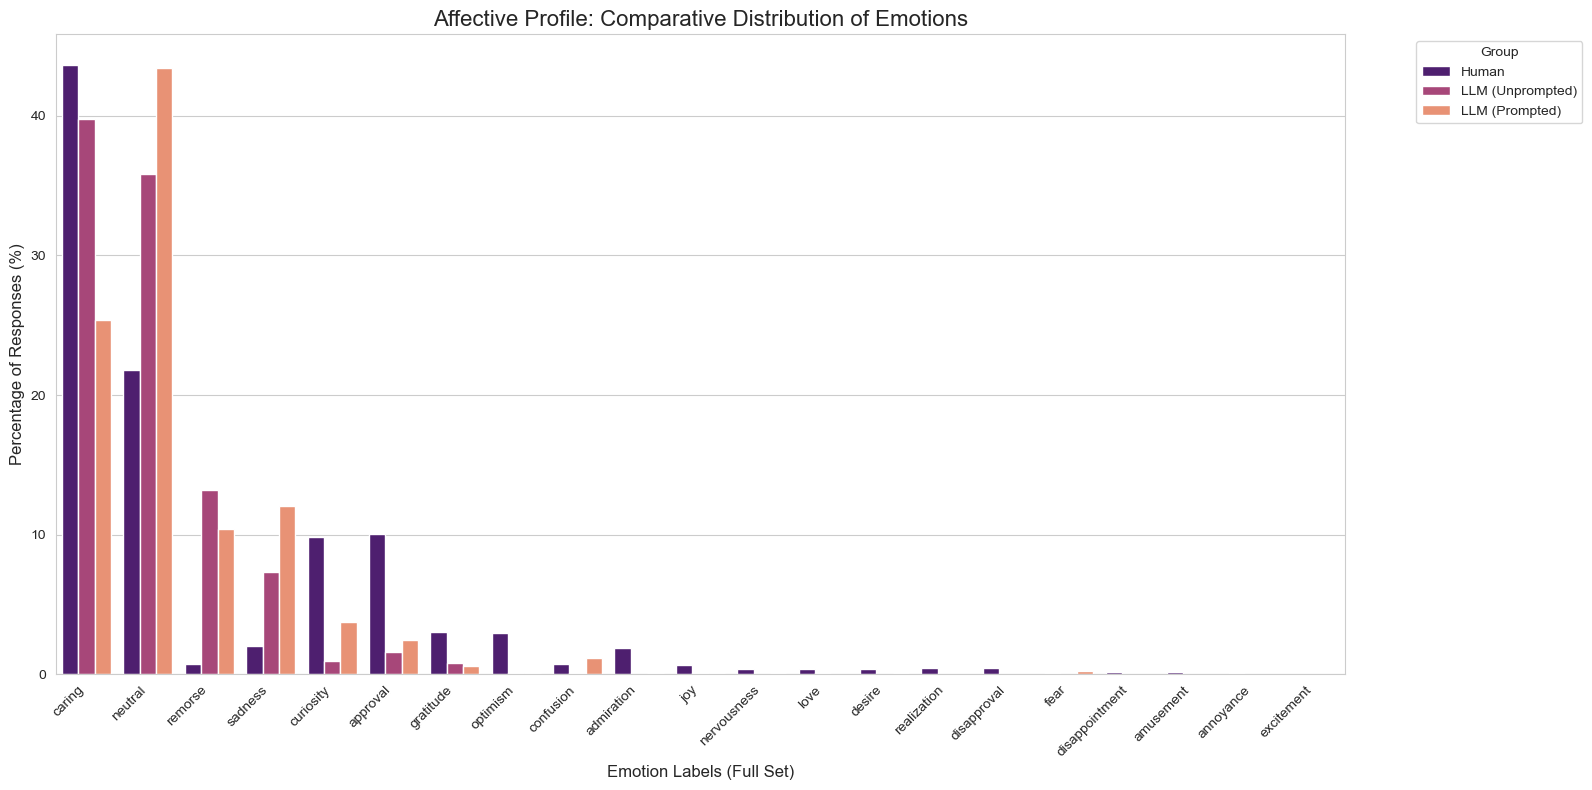

In [70]:
def plot_emotion_distribution_fixed(dfh, dfllm):
    #Get frequencies for each group
    human_counts = dfh['emotion_human'].value_counts(normalize=True).rename('Human')
    unprompted_counts = dfllm['emotion_unprompted'].value_counts(normalize=True).rename('LLM (Unprompted)')
    prompted_counts = dfllm['emotion_prompted'].value_counts(normalize=True).rename('LLM (Prompted)')

    #Create the combined DataFrame
    viz_df = pd.concat([human_counts, unprompted_counts, prompted_counts], axis=1).fillna(0)
    viz_df = viz_df.reset_index().rename(columns={'index': 'Emotion'})

    #Calculate Total Frequency to determine the sort order
    viz_df['Total'] = viz_df['Human'] + viz_df['LLM (Unprompted)'] + viz_df['LLM (Prompted)']
    sort_order = viz_df.sort_values('Total', ascending=False)['Emotion'].tolist()

    #Melt the data for Seaborn
    melted_df = viz_df.drop(columns=['Total']).melt(id_vars='Emotion', var_name='Group', value_name='Percentage')
    melted_df['Percentage'] = melted_df['Percentage'] * 100

    #Plotting
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")
    
    ax = sns.barplot(
        data=melted_df, 
        x='Emotion', 
        y='Percentage', 
        hue='Group',
        order=sort_order,
        palette='magma'   
    )

    plt.title('Affective Profile: Comparative Distribution of Emotions', fontsize=16)
    plt.xlabel('Emotion Labels (Full Set)', fontsize=12)
    plt.ylabel('Percentage of Responses (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left') 
    
    plt.tight_layout()
    plt.savefig("emotion_distribution_full.png")
    print("Full distribution chart saved as 'emotion_distribution_full.png'")

plot_emotion_distribution_fixed(dfh, dfllm)

C:\Users\bolly\AppData\Local\Temp\ipykernel_8320\53004384.py:11: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


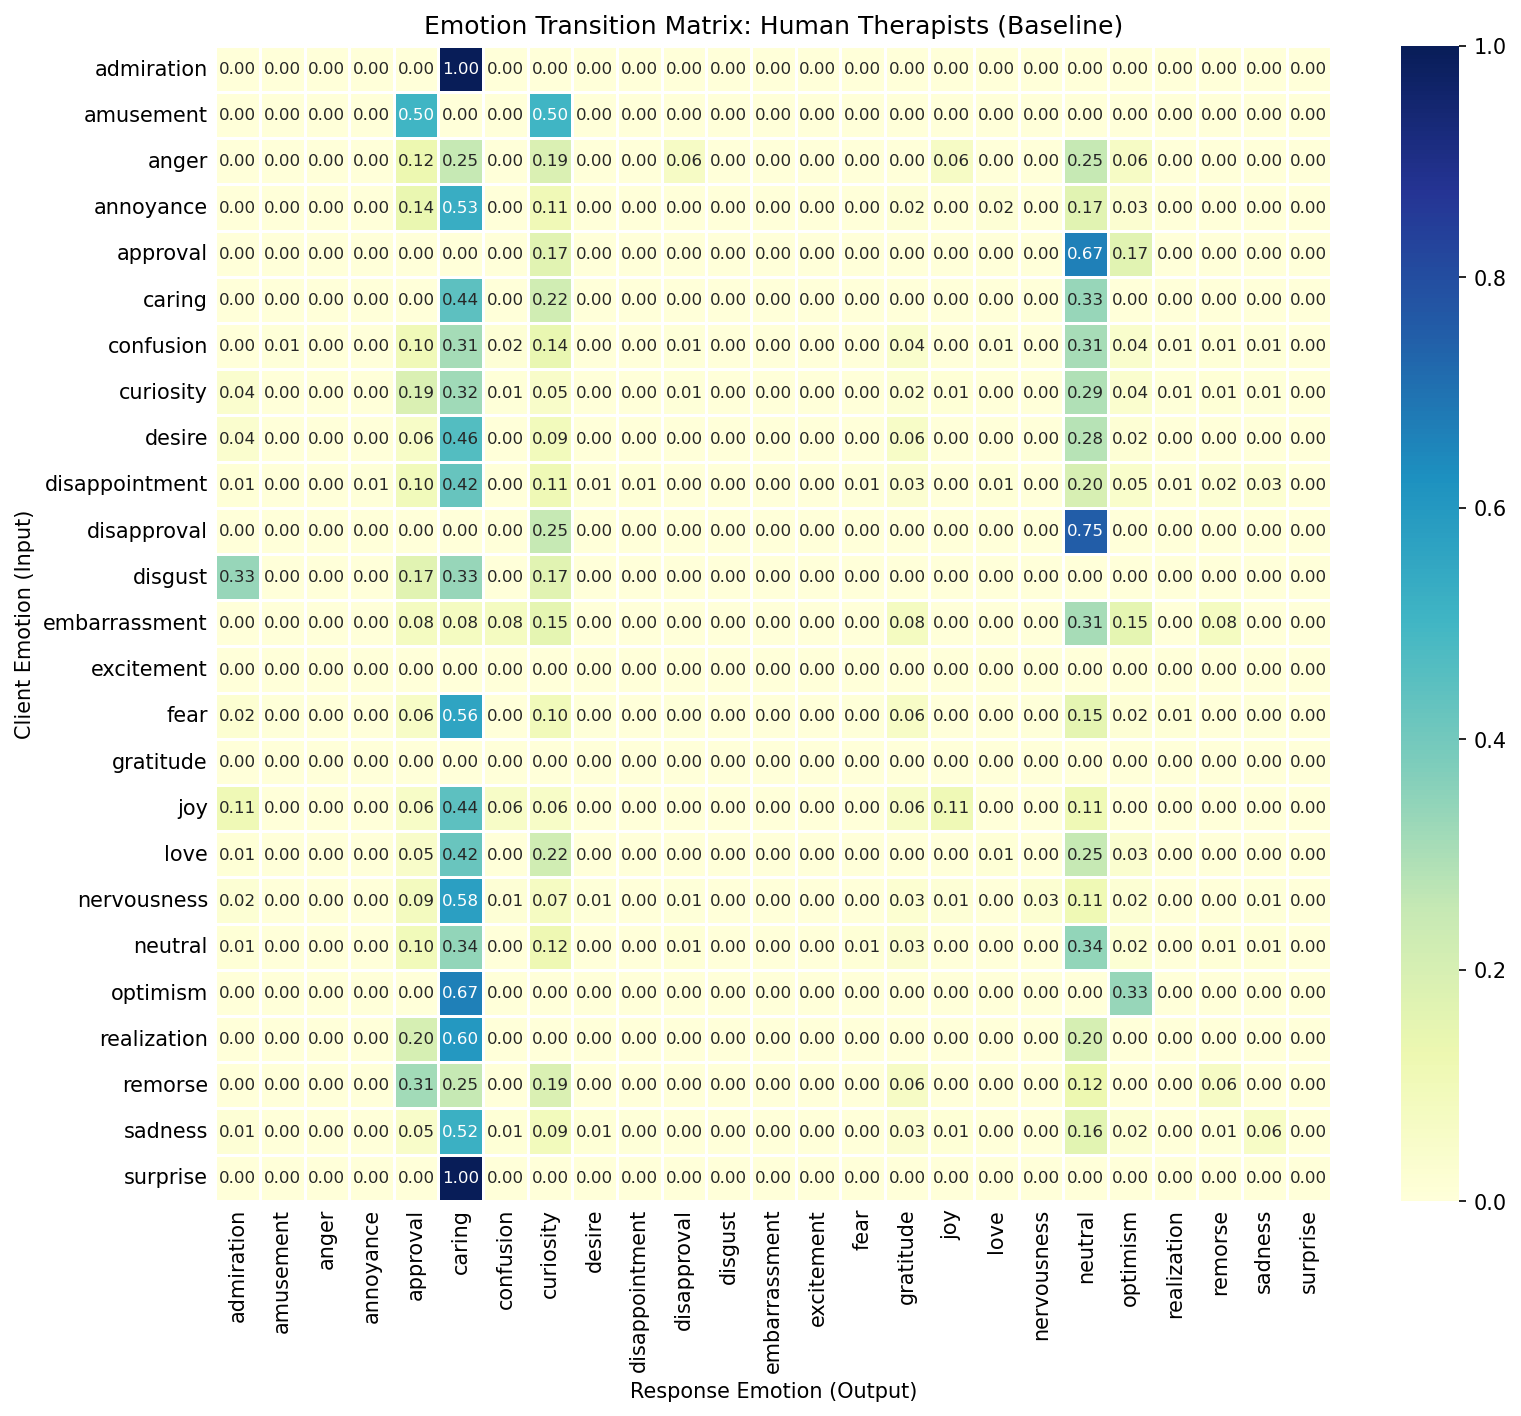

C:\Users\bolly\AppData\Local\Temp\ipykernel_8320\53004384.py:11: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


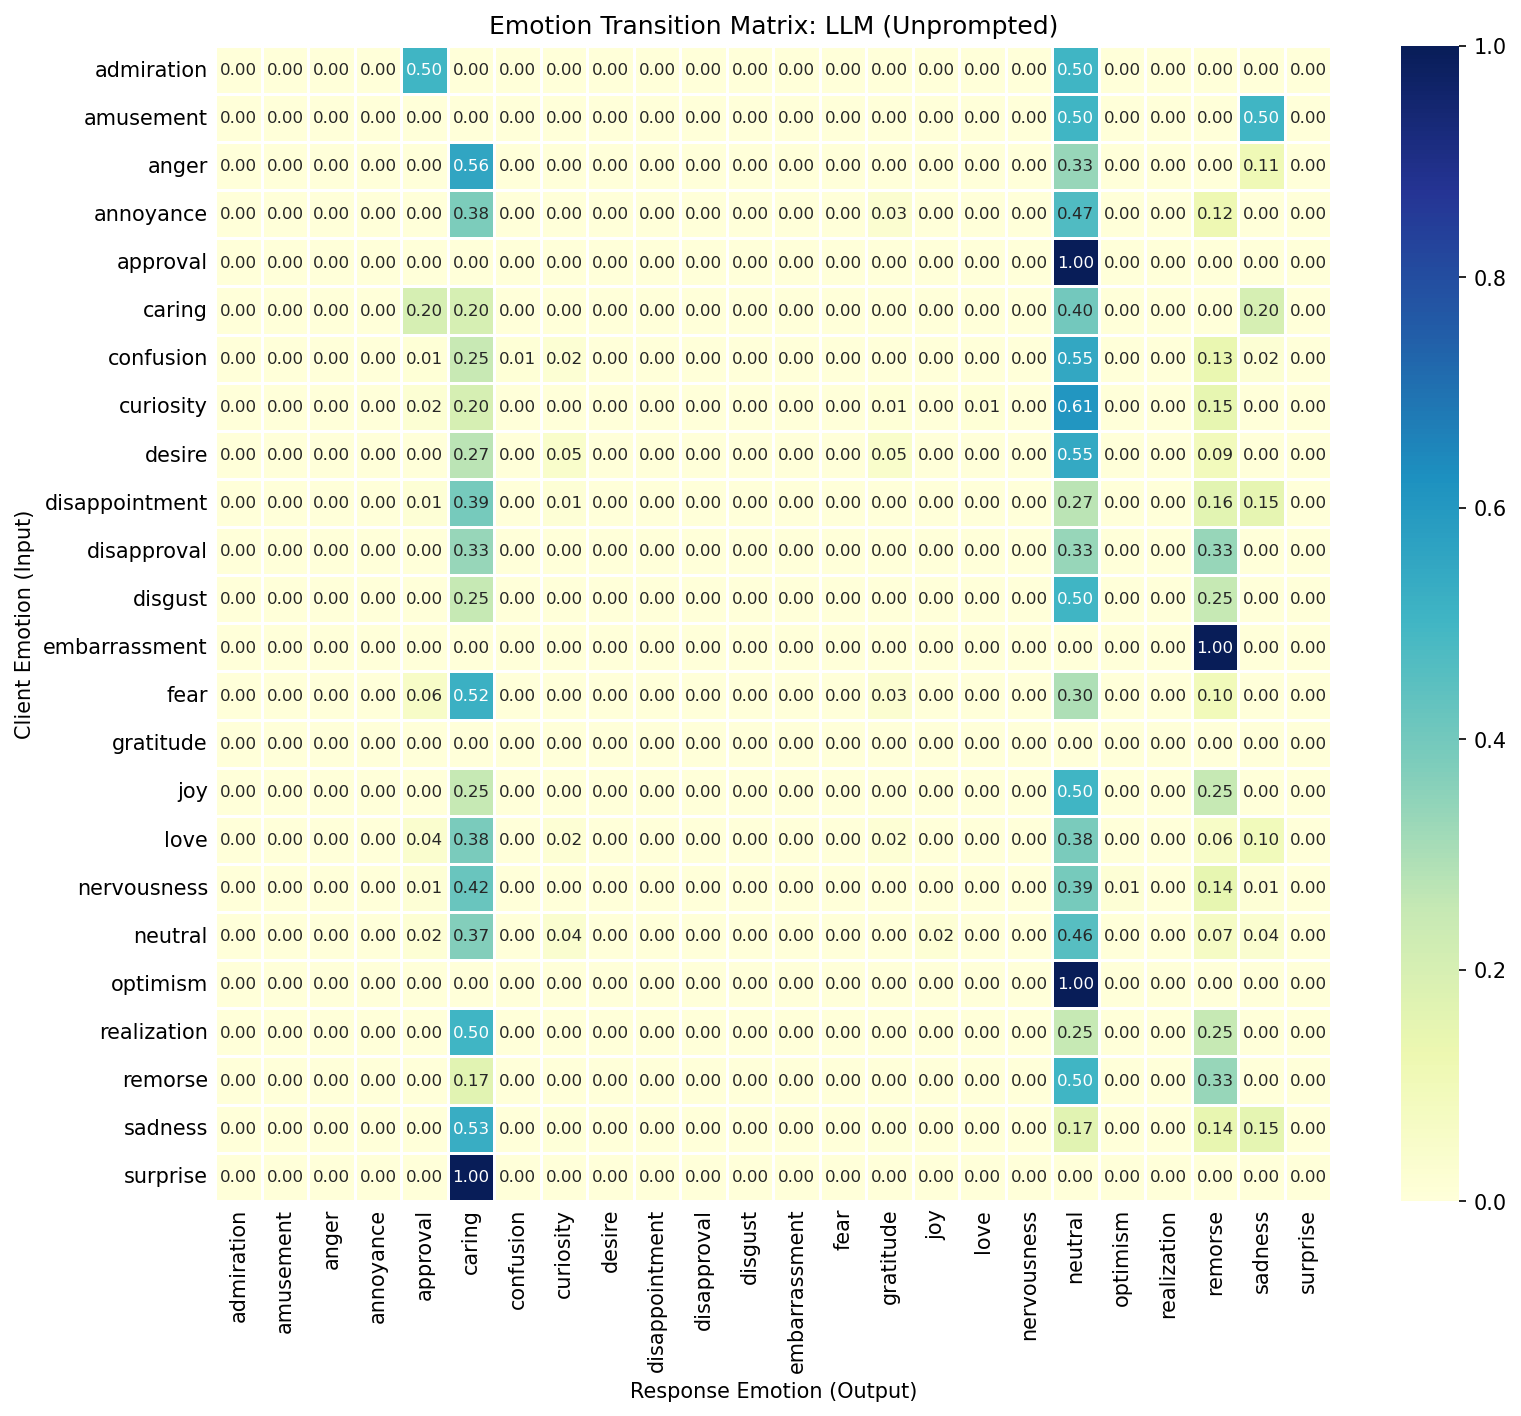

C:\Users\bolly\AppData\Local\Temp\ipykernel_8320\53004384.py:11: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


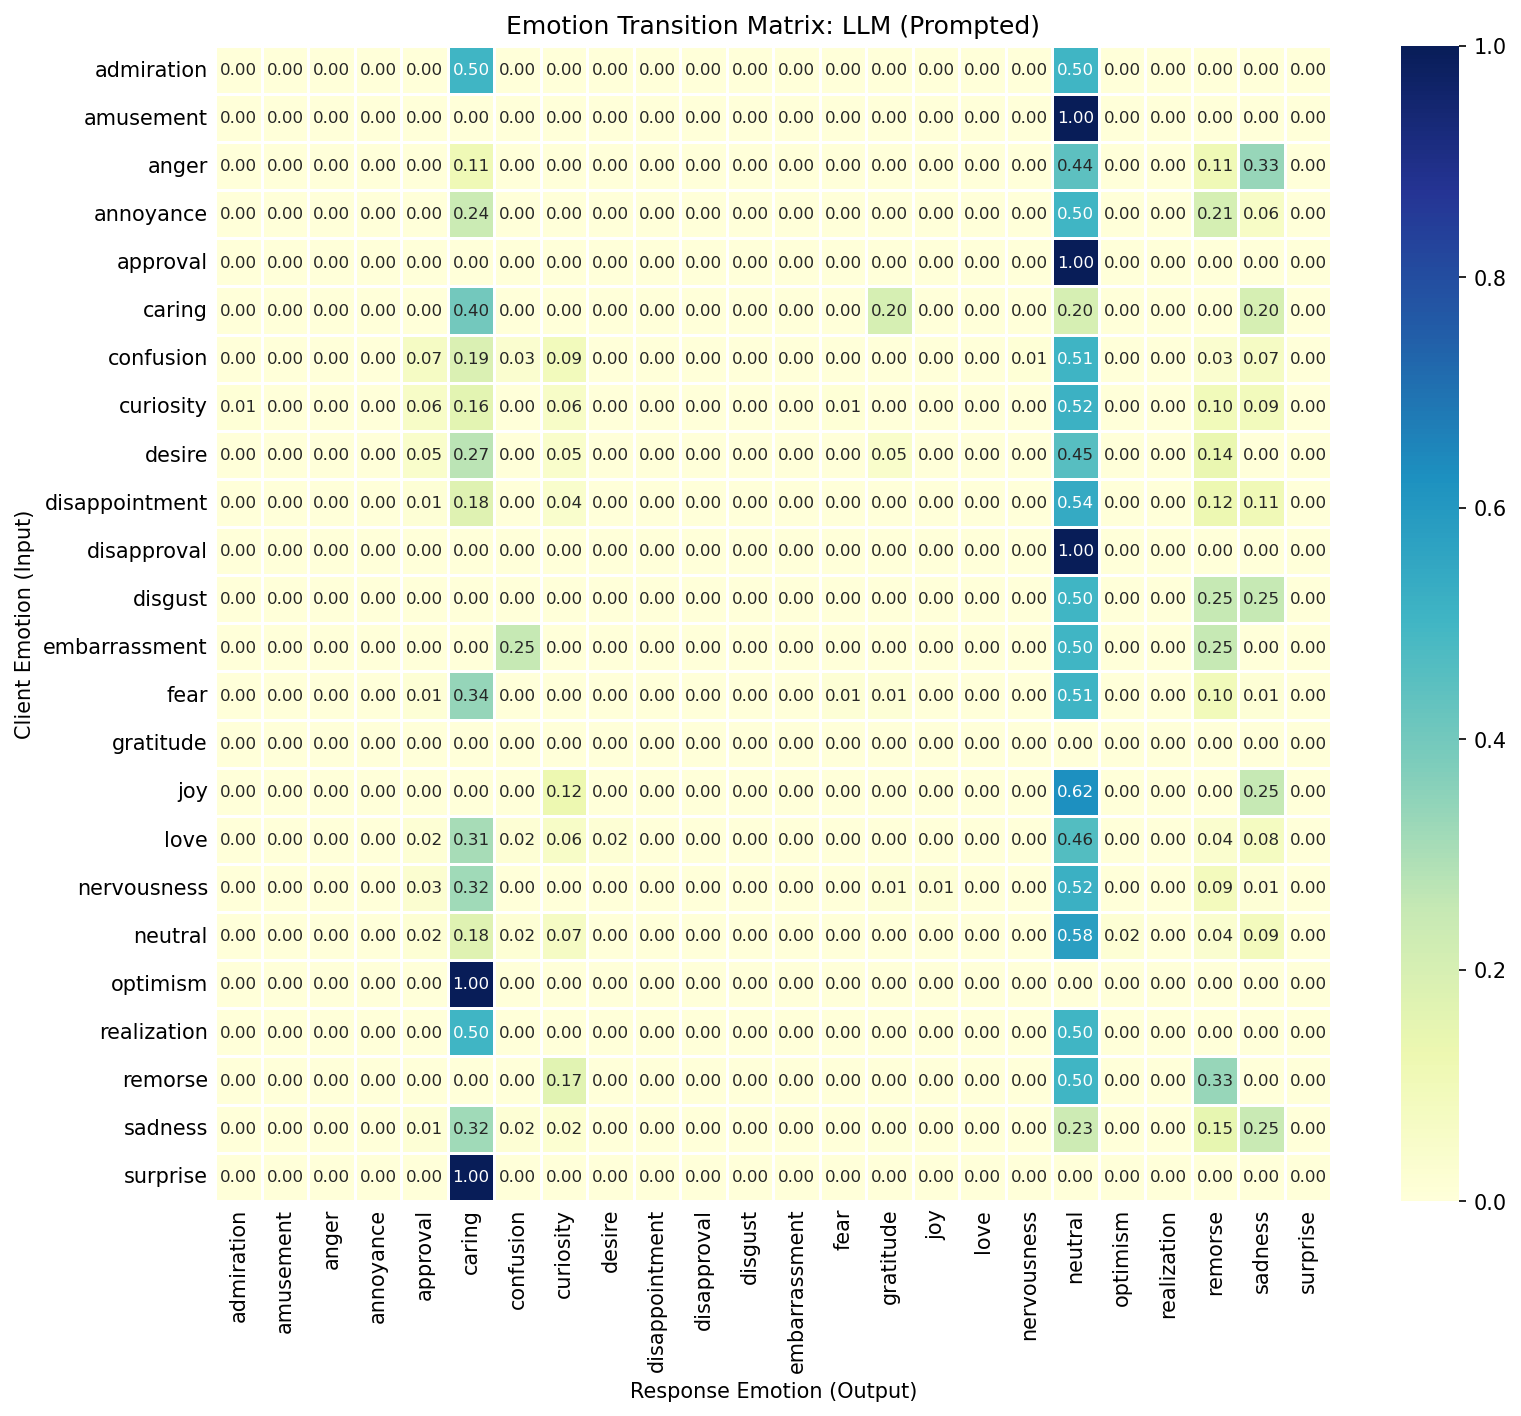

In [56]:
dfh = pd.read_csv("human_classified_emotions.csv")
dfllm = pd.read_csv("llm_classified_emotions.csv")

def plot_emotion_matrix(df, response_col, title):
    emotions = sorted(list(set(df['emotion_q'].unique()) | set(df[response_col].unique())))
    
    #Create the confusion matrix
    cm = confusion_matrix(df['emotion_q'], df[response_col], labels=emotions)
    
    #Normalize by row 
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm) # Replace NaNs with 0

    
    #Plotting
    plt.figure(figsize=(12, 10), dpi=150)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu",
        xticklabels=emotions,
        yticklabels=emotions,
        annot_kws={"size": 8},
        linewidths=0.5,
        linecolor="white"
    )
    
    plt.title(f"Emotion Transition Matrix: {title}")
    plt.xlabel("Response Emotion (Output)")
    plt.ylabel("Client Emotion (Input)")
    plt.tick_params(axis='both', length=0)
    filename = title.lower().replace(" ", "_") + ".png"
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()

plot_emotion_matrix(dfh, 'emotion_human', "Human Therapists (Baseline)")
plot_emotion_matrix(dfllm, 'emotion_unprompted', "LLM (Unprompted)")
plot_emotion_matrix(dfllm, 'emotion_prompted', "LLM (Prompted)")

In [78]:
#Check how many times each emotion appeared in the LLM subset
print("Frequency of Client Emotions (Input):")
print(dfllm['emotion_q'].value_counts())

Frequency of Client Emotions (Input):
emotion_q
sadness           253
confusion          89
curiosity          89
disappointment     74
fear               71
nervousness        69
neutral            57
love               52
annoyance          34
desire             22
anger               9
joy                 8
remorse             6
caring              5
disgust             4
embarrassment       4
realization         4
approval            3
disapproval         3
amusement           2
admiration          2
optimism            1
surprise            1
Name: count, dtype: int64


## Chi Square Test to Ensure Significance

In [167]:
df_human = pd.read_csv('human_classified_emotions.csv')
df_llm = pd.read_csv('llm_classified_emotions.csv')

#Extract frequency counts
human_counts = df_human['emotion_human'].value_counts()
unprompted_counts = df_llm['emotion_unprompted'].value_counts()
prompted_counts = df_llm['emotion_prompted'].value_counts()

#Contingency Table
ct = pd.DataFrame({
    'Human': human_counts,
    'Unprompted': unprompted_counts,
    'Prompted': prompted_counts
}).fillna(0)  # Replace NaN with 0 if an emotion didn't appear in a group

print("--- Contingency Table (First 5 emotions) ---")
print(ct.head())

#Chi-Square Test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"\n--- Statistical Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
print(f"Degrees of Freedom: {dof}")

#Effect Size
n = ct.values.sum()
min_dim = min(ct.shape[0] - 1, ct.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramer's V Effect Size: {cramers_v:.4f}")

--- Contingency Table (First 5 emotions) ---
            Human  Unprompted  Prompted
admiration     50         0.0       1.0
amusement       5         0.0       0.0
annoyance       3         0.0       0.0
approval      263        14.0      21.0
caring       1139       343.0     219.0

--- Statistical Results ---
Chi-Square Statistic: 915.9205
P-value: 3.9754e-166
Degrees of Freedom: 40
Cramer's V Effect Size: 0.3251


In [181]:
#Add Laplace Smoothing (+0.5 is standard)
ct_smoothed = ct + 0.5

#Global Chi-Square Test
chi2_total, p_total, dof_total, ex_total = chi2_contingency(ct_smoothed)

print(f"GLOBAL RESULTS (Smoothed)")
print(f"Chi-square: {chi2_total:.2f}, p-value: {p_total:.4e}\n")

#Post-Hoc Pairwise Comparisons
pairs = list(itertools.combinations(ct.columns, 2))
adj_alpha = 0.05 / len(pairs) # Bonferroni Correction

posthoc_results = []
for p1, p2 in pairs:
    #Isolate the two columns for comparison
    pair_table = ct_smoothed[[p1, p2]]
    chi2, p, dof, ex = chi2_contingency(pair_table)
    
    #Effect Size
    n_pair = pair_table.values.sum()
    min_dim_pair = min(pair_table.shape[0] - 1, pair_table.shape[1] - 1)
    cramers_v = np.sqrt(chi2 / (n_pair * min_dim_pair))
    is_sig = "Significant" if p < adj_alpha else "Not Significant"
    
    posthoc_results.append({
        'Comparison': f"{p1} vs {p2}", 
        'p-value': p, 
        'Cramer\'s V': round(cramers_v, 4),
        'Result': is_sig
    })

df_posthoc = pd.DataFrame(posthoc_results)
print(df_posthoc)

GLOBAL RESULTS (Smoothed)
Chi-square: 890.63, p-value: 7.2477e-161

               Comparison        p-value  Cramer's V       Result
0     Human vs Unprompted  1.999564e-106      0.4014  Significant
1       Human vs Prompted  1.100852e-123      0.4296  Significant
2  Unprompted vs Prompted   8.226706e-08      0.2033  Significant


# Empathic Word Density

Next, Empath will be used to assess the amount of emotional words in specific categories used by both the Human and LLM therapists.

Analyzing word density for Humans...
Analyzing word density for Prompted LLM...
Analyzing word density for Prompted LLM...


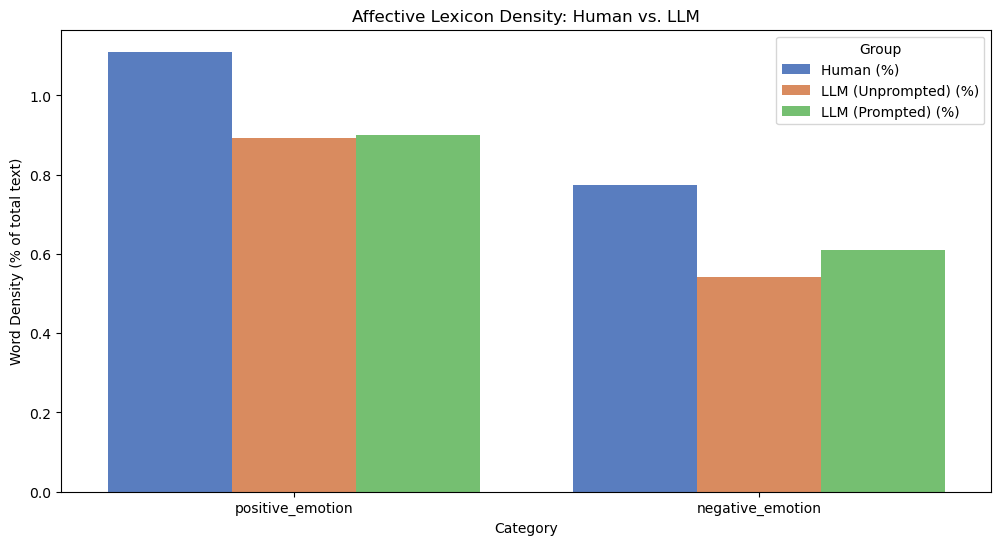

   positive_emotion  negative_emotion  Group
0          0.000000             0.000  Human
1          0.000000             0.000  Human
2          0.000000             0.000  Human
3          0.007353             0.000  Human
4          0.000000             0.005  Human


In [26]:
lexicon = Empath()
target_categories = ["positive_emotion", "negative_emotion"]

def get_word_density(text):
    if pd.isna(text) or str(text).strip() == "":
        return {cat: 0.0 for cat in target_categories}
    
    res = lexicon.analyze(text, categories=target_categories, normalize=True)
    
    if res is None:
        return {cat: 0.0 for cat in target_categories}
    return res

#Apply the formula to the subsets
#Create a density score for each group
print("Analyzing word density for Humans...")
human_results = human_subset['answerText'].apply(get_word_density).apply(pd.Series)

print("Analyzing word density for Prompted LLM...")
llm_results = llm_subset_unique['LLM_unprompted'].apply(get_word_density).apply(pd.Series)

print("Analyzing word density for Prompted LLM...")
pllm_results = llm_subset_unique['LLM_prompted'].apply(get_word_density).apply(pd.Series)

#Calculate the average density for the final report
human_means = human_results.mean() * 100 #Convert to percentage
llm_means = llm_results.mean() * 100
pllm_means = pllm_results.mean() * 100

#Combine for comparison
comparison_df = pd.DataFrame({
    'Category': target_categories,
    'Human (%)': human_means.values,
    'LLM (Unprompted) (%)': llm_means.values,
    'LLM (Prompted) (%)': pllm_means.values
}).melt(id_vars='Category', var_name='Group', value_name='Density')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Category', y='Density', hue='Group', palette='muted')
plt.title('Affective Lexicon Density: Human vs. LLM')
plt.ylabel('Word Density (% of total text)')
plt.savefig('EmpathSimple.png', dpi=300, bbox_inches='tight')
plt.show()

#Add a 'Group' column to each dataframe for statistical tests
human_results['Group'] = 'Human'
llm_results['Group'] = 'Unprompted'
pllm_results['Group'] = 'Prompted'
empath_stats_df = pd.concat([human_results, llm_results, pllm_results], axis=0)

empath_stats_df.to_csv('empath_raw_results.csv', index=False)
print(empath_stats_df.head())

## Statistical Test

In [28]:
df = pd.read_csv('empath_raw_results.csv')

for cat in target_categories:
    #Separate the values by group
    h_vals = empath_stats_df[empath_stats_df['Group'] == 'Human'][cat]
    un_vals = empath_stats_df[empath_stats_df['Group'] == 'Unprompted'][cat]
    pr_vals = empath_stats_df[empath_stats_df['Group'] == 'Prompted'][cat]
    
    #Run Kruskal-Wallis
    stat, p = kruskal(h_vals, un_vals, pr_vals)
    
    print(f"--- Statistics for {cat} ---")
    print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")
    if p < 0.05:
        print("Result: Significant Difference\n")
    else:
        print("Result: No Significant Difference\n")

--- Statistics for positive_emotion ---
Kruskal-Wallis H-statistic: 4.7395
P-value: 9.3502e-02
Result: No Significant Difference

--- Statistics for negative_emotion ---
Kruskal-Wallis H-statistic: 9.9432
P-value: 6.9321e-03
Result: Significant Difference



Analyzing word density for Humans...
Analyzing word density for Prompted LLM...
Analyzing word density for Prompted LLM...


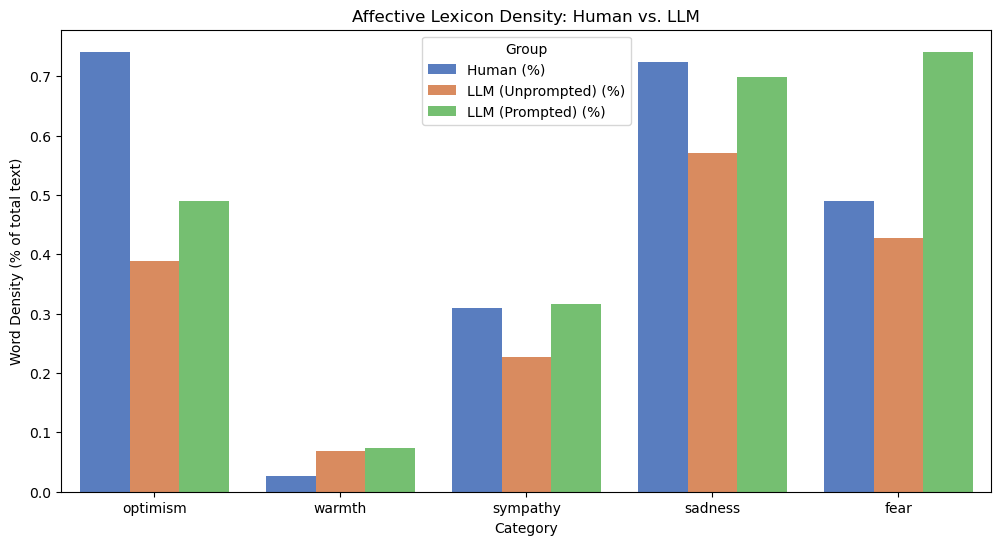

   optimism  warmth  sympathy   sadness      fear  Group
0  0.000000     0.0  0.000000  0.005814  0.011628  Human
1  0.000000     0.0  0.000000  0.000000  0.000000  Human
2  0.000000     0.0  0.000000  0.000000  0.000000  Human
3  0.007353     0.0  0.003676  0.011029  0.003676  Human
4  0.010000     0.0  0.000000  0.015000  0.010000  Human


In [30]:
lexicon = Empath()
target_categories = ["optimism", "warmth", "sympathy", "sadness", "fear"]

def get_word_density(text):
    if pd.isna(text) or str(text).strip() == "":
        return {cat: 0.0 for cat in target_categories}
    
    res = lexicon.analyze(text, categories=target_categories, normalize=True)
    
    if res is None:
        return {cat: 0.0 for cat in target_categories}
    return res

#Apply the formula to the subsets
#Create a density score for each group
print("Analyzing word density for Humans...")
human_results = human_subset['answerText'].apply(get_word_density).apply(pd.Series)

print("Analyzing word density for Prompted LLM...")
llm_results = llm_subset_unique['LLM_unprompted'].apply(get_word_density).apply(pd.Series)

print("Analyzing word density for Prompted LLM...")
pllm_results = llm_subset_unique['LLM_prompted'].apply(get_word_density).apply(pd.Series)

#Calculate the average density for the final report
human_means = human_results.mean() * 100 #Convert to percentage
llm_means = llm_results.mean() * 100
pllm_means = pllm_results.mean() * 100

#Combine for comparison
comparison_df = pd.DataFrame({
    'Category': target_categories,
    'Human (%)': human_means.values,
    'LLM (Unprompted) (%)': llm_means.values,
    'LLM (Prompted) (%)': pllm_means.values
}).melt(id_vars='Category', var_name='Group', value_name='Density')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='Category', y='Density', hue='Group', palette='muted')
plt.title('Affective Lexicon Density: Human vs. LLM')
plt.ylabel('Word Density (% of total text)')
plt.savefig('EmpathDetail.png', dpi=300, bbox_inches='tight')
plt.show()

#Add a 'Group' column to each dataframe for statistical tests
human_results['Group'] = 'Human'
llm_results['Group'] = 'Unprompted'
pllm_results['Group'] = 'Prompted'
empath_stats_df = pd.concat([human_results, llm_results, pllm_results], axis=0)

empath_stats_df.to_csv('empath_granular_raw_results.csv', index=False)
print(empath_stats_df.head())

## Statistical Test

In [32]:
df = pd.read_csv('empath_granular_raw_results.csv')

for cat in target_categories:
    #Separate the values by group
    h_vals = empath_stats_df[empath_stats_df['Group'] == 'Human'][cat]
    un_vals = empath_stats_df[empath_stats_df['Group'] == 'Unprompted'][cat]
    pr_vals = empath_stats_df[empath_stats_df['Group'] == 'Prompted'][cat]
    
    #Run Kruskal-Wallis
    stat, p = kruskal(h_vals, un_vals, pr_vals)
    
    print(f"--- Statistics for {cat} ---")
    print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
    print(f"P-value: {p:.4e}")
    if p < 0.05:
        print("Result: Significant Difference\n")
    else:
        print("Result: No Significant Difference\n")

--- Statistics for optimism ---
Kruskal-Wallis H-statistic: 82.0685
P-value: 1.5103e-18
Result: Significant Difference

--- Statistics for warmth ---
Kruskal-Wallis H-statistic: 123.6511
P-value: 1.4109e-27
Result: Significant Difference

--- Statistics for sympathy ---
Kruskal-Wallis H-statistic: 28.6821
P-value: 5.9124e-07
Result: Significant Difference

--- Statistics for sadness ---
Kruskal-Wallis H-statistic: 22.9606
P-value: 1.0331e-05
Result: Significant Difference

--- Statistics for fear ---
Kruskal-Wallis H-statistic: 231.4685
P-value: 5.4607e-51
Result: Significant Difference



# BERTScore

BERTScore is used to measure the semantic alignment between the human therapists' responses and the LLM responses

Calculating Consensus BERTScore for 862 unique scenarios...

Final Consensus Scores:
Unprompted: 0.8214
Prompted:   0.8246


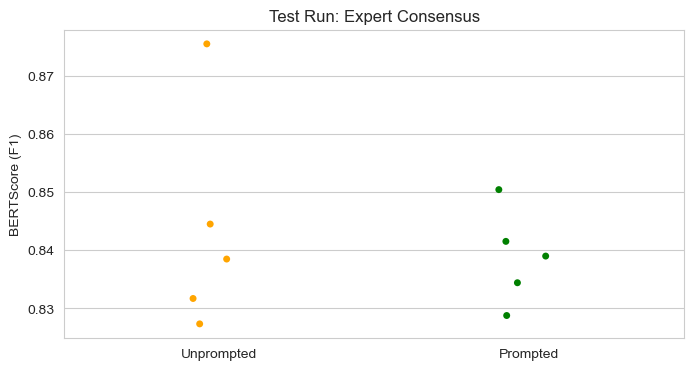

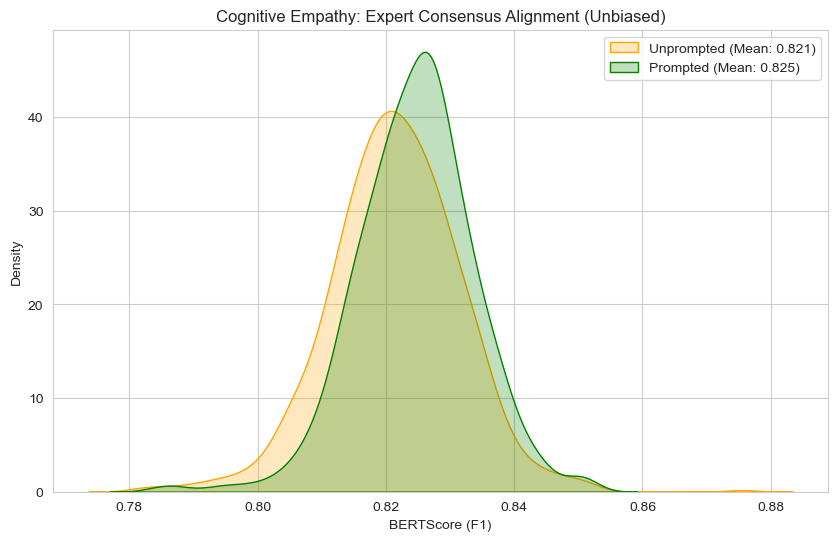

In [62]:
df_unique = llm_subset_unique.copy()
#Silence all Python and Logging warnings
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
#Group the human responses by question so the AI has a "list of experts" to compare against
human_groups = llmdf.groupby('questionText')['answerText'].apply(list).to_dict()

#Function to compare one AI response to all human references for that question
def get_consensus_score(row, target_col):
    q_text = row['questionText']
    ai_response = str(row[target_col])
    human_references = [str(h) for h in human_groups.get(q_text, [])]
    
    if not human_references:
        return None

    P, R, F1 = score([ai_response], [human_references], lang="en", device='cpu') 
    return F1.item()

print(f"Calculating Consensus BERTScore for {len(df_unique)} unique scenarios...")

#Apply the consensus logic
df_unique['consensus_f1_un'] = df_unique.apply(lambda r: get_consensus_score(r, 'LLM_unprompted'), axis=1)
df_unique['consensus_f1_pr'] = df_unique.apply(lambda r: get_consensus_score(r, 'LLM_prompted'), axis=1)

#Final Results
avg_un = df_unique['consensus_f1_un'].mean()
avg_pr = df_unique['consensus_f1_pr'].mean()

print(f"\nFinal Consensus Scores:")
print(f"Unprompted: {avg_un:.4f}")
print(f"Prompted:   {avg_pr:.4f}")

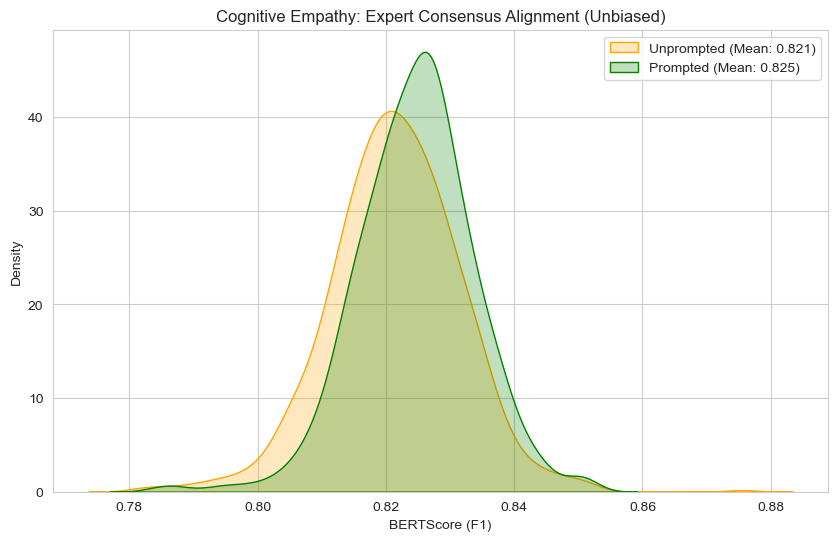

In [89]:
#Visualization
plt.figure(figsize=(10, 6))
sns.kdeplot(df_unique['consensus_f1_un'], label=f"Unprompted (Mean: {avg_un:.3f})", fill=True, color="orange")
sns.kdeplot(df_unique['consensus_f1_pr'], label=f"Prompted (Mean: {avg_pr:.3f})", fill=True, color="green")
plt.title("Cognitive Empathy: Expert Consensus Alignment (Unbiased)")
plt.xlabel("BERTScore (F1)")
plt.legend()
plt.savefig('BERTScore.png', dpi=300, bbox_inches='tight')

plt.show()

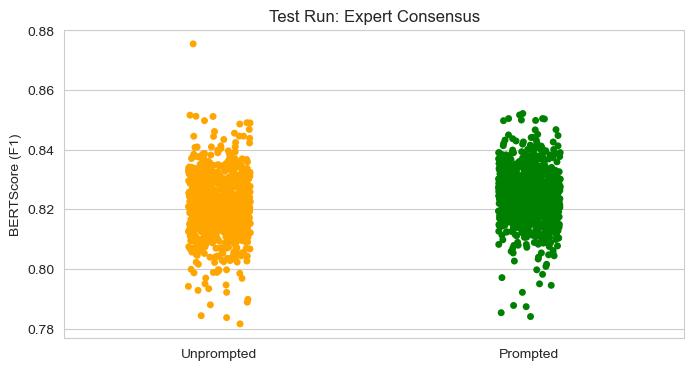

In [91]:
#KDE Plot
plt.figure(figsize=(8, 4))
sns.stripplot(data=df_unique[['consensus_f1_un', 'consensus_f1_pr']], palette=['orange', 'green'])
plt.title("Test Run: Expert Consensus")
plt.ylabel("BERTScore (F1)")
plt.xticks([0, 1], ['Unprompted', 'Prompted'])
plt.savefig('BERTScoreKDE.png', dpi=300, bbox_inches='tight')

plt.show()

In [75]:
df_unique.to_csv("llm_unique_with_bertscores.csv", index=False)

Scores successfully saved to 'llm_unique_with_bertscores.csv'


## Statistical Test

In [38]:
df_bert = pd.read_csv('llm_unique_with_bertscores.csv')

#Calculate the difference
diff = df_bert['consensus_f1_pr'] - df_bert['consensus_f1_un']

#Check for normality
_, p_norm = shapiro(diff.dropna())

#Run the paired test
if p_norm > 0.05:
    stat, p_val = ttest_rel(df_bert['consensus_f1_pr'], df_bert['consensus_f1_un'], nan_policy='omit')
    test_type = "Paired T-test"
else:
    stat, p_val = wilcoxon(df_bert['consensus_f1_pr'], df_bert['consensus_f1_un'])
    test_type = "Wilcoxon Signed-Rank test"

print(f"Test Type: {test_type}")
print(f"P-value: {p_val:.4e}")
print(f"Prompted Mean: {df_bert['consensus_f1_pr'].mean():.4f}")
print(f"Unprompted Mean: {df_bert['consensus_f1_un'].mean():.4f}")

Test Type: Wilcoxon Signed-Rank test
P-value: 8.9308e-42
Prompted Mean: 0.8246
Unprompted Mean: 0.8214


# Named Entity Recognition

Named entity recognition is used to measure the amount of overlapping entities between questions and responses

Analyzing Topical Specificity (NER Overlap)...

Average Entity Overlap:
Human Experts:     11.17%
LLM (Unprompted): 23.89%
LLM (Prompted):   20.00%


C:\Users\bolly\AppData\Local\Temp\ipykernel_12688\2987512895.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Group', y='Overlap', palette='viridis')


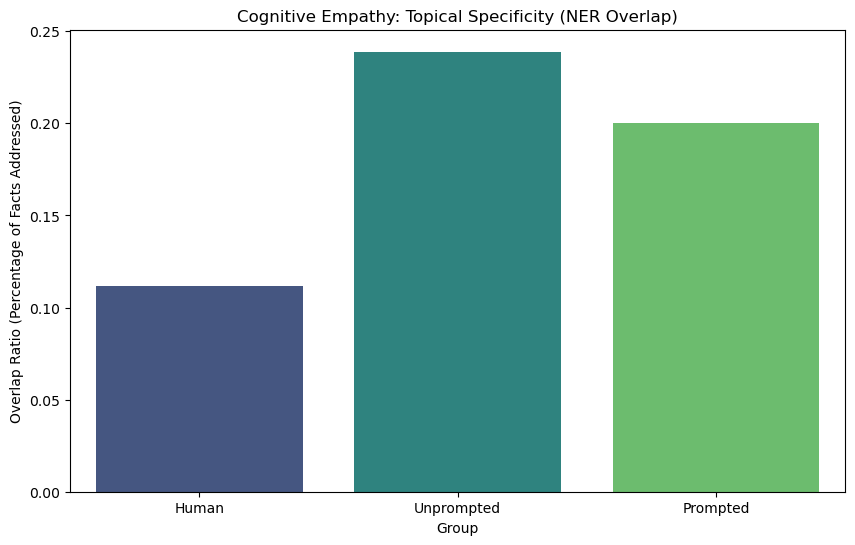

In [40]:
#Load the NLP engine
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    if pd.isna(text) or str(text).strip() == "":
        return set()
    doc = nlp(str(text))
    #Define entities to target clinical facts
    return set([ent.text.lower().strip() for ent in doc.ents if ent.label_ in ['PERSON', 'GPE', 'ORG', 'PRODUCT', 'EVENT']])

def get_overlap_ratio(prompt, response):
    prompt_ents = extract_entities(prompt)
    response_ents = extract_entities(response)
    
    if not prompt_ents:
        return None 
    
    overlap = prompt_ents.intersection(response_ents)
    return len(overlap) / len(prompt_ents)

print("Analyzing Topical Specificity (NER Overlap)...")

#AI Results
llm_subset_unique['ner_overlap_un'] = llm_subset_unique.apply(
    lambda r: get_overlap_ratio(r['questionText'], r['LLM_unprompted']), axis=1)
llm_subset_unique['ner_overlap_pr'] = llm_subset_unique.apply(
    lambda r: get_overlap_ratio(r['questionText'], r['LLM_prompted']), axis=1)

#Human Baseline
human_subset['ner_overlap'] = human_subset.apply(
    lambda r: get_overlap_ratio(r['questionText'], r['answerText']), axis=1)

#Summarize
h_mean = human_subset['ner_overlap'].dropna().mean()
un_mean = llm_subset_unique['ner_overlap_un'].dropna().mean()
pr_mean = llm_subset_unique['ner_overlap_pr'].dropna().mean()

print(f"\nAverage Entity Overlap:")
print(f"Human Experts:     {h_mean:.2%}")
print(f"LLM (Unprompted): {un_mean:.2%}")
print(f"LLM (Prompted):   {pr_mean:.2%}")

#Visualization
plot_data = pd.DataFrame({
    'Group': ['Human', 'Unprompted', 'Prompted'],
    'Overlap': [h_mean, un_mean, pr_mean]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_data, x='Group', y='Overlap', palette='viridis')
plt.title("Cognitive Empathy: Topical Specificity (NER Overlap)")
plt.ylabel("Overlap Ratio (Percentage of Facts Addressed)")
plt.savefig('ner_overlap_bridge.png', dpi=300, bbox_inches='tight')
plt.show()

#Prepare raw scores for saving
#Human scores
h_scores = human_subset[['ner_overlap']].dropna().rename(columns={'ner_overlap': 'overlap'})
h_scores['Group'] = 'Human'

#Unprompted scores
un_scores = llm_subset_unique[['ner_overlap_un']].dropna().rename(columns={'ner_overlap_un': 'overlap'})
un_scores['Group'] = 'Unprompted'

#Prompted scores
pr_scores = llm_subset_unique[['ner_overlap_pr']].dropna().rename(columns={'ner_overlap_pr': 'overlap'})
pr_scores['Group'] = 'Prompted'

#Combine and Save
ner_raw_df = pd.concat([h_scores, un_scores, pr_scores], axis=0)
ner_raw_df.to_csv('ner_overlap_raw.csv', index=False)

## Statistical Test

In [42]:
#Group data for testing
h_vals = ner_raw_df[ner_raw_df['Group'] == 'Human']['overlap']
un_vals = ner_raw_df[ner_raw_df['Group'] == 'Unprompted']['overlap']
pr_vals = ner_raw_df[ner_raw_df['Group'] == 'Prompted']['overlap']

#Run test
h_stat, p_val = kruskal(h_vals, un_vals, pr_vals)

print(f"--- Statistics for NER Overlap ---")
print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4e}")

--- Statistics for NER Overlap ---
Kruskal-Wallis H-statistic: 5.1203
P-value: 7.7293e-02


In [52]:
#Run Dunn's test with Bonferroni correction
posthoc_ner = sp.posthoc_dunn(ner_raw_df, val_col='overlap', group_col='Group', p_adjust='bonferroni')

print("--- Post-Hoc Dunn's Test (NER Overlap) ---")
print(posthoc_ner)

--- Post-Hoc Dunn's Test (NER Overlap) ---
               Human  Prompted  Unprompted
Human       1.000000  0.602598    0.090671
Prompted    0.602598  1.000000    1.000000
Unprompted  0.090671  1.000000    1.000000


# Mechanism of Action Detection

In [55]:
#Initialize the Zero-Shot Classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1) # device=-1 for CPU

#Define the labels
#'Interpretive/Explorative' = High Cognitive Empathy
#'Generic/Surface' = Low Cognitive Empathy
candidate_labels = ["Interpretive or Explorative", "Generic or Surface Response"]

def detect_mechanism(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    
    result = classifier(text, candidate_labels, multi_label=False)    
    return result['labels'][0]

#Apply
print("Analyzing communication mechanisms (Test Sample)...")
test_df = llm_subset_unique.copy()
htest_df = human_subset.copy()

htest_df['mech'] = htest_df['answerText'].apply(detect_mechanism)
test_df['mech_un'] = test_df['LLM_unprompted'].apply(detect_mechanism)
test_df['mech_pr'] = test_df['LLM_prompted'].apply(detect_mechanism)

#Compare the shift
h_ratio = (htest_df['mech'] == "Interpretive or Explorative").mean()
un_interpretive = (test_df['mech_un'] == "Interpretive or Explorative").mean()
pr_interpretive = (test_df['mech_pr'] == "Interpretive or Explorative").mean()

htest_df.to_csv('human_mechanism_results.csv', index=False)
test_df.to_csv('llm_mechanism_results.csv', index=False)

print(f"\nInterpretive/Explorative Content Ratio:")
print(f"Interpretive Content Human Experts:    {h_ratio:.2%}")
print(f"Interpretive Content (Unprompted): {un_interpretive:.2%}")
print(f"Interpretive Content (Prompted):   {pr_interpretive:.2%}")


Analyzing communication mechanisms (Test Sample)...

Interpretive/Explorative Content Ratio:
Interpretive Content Human Experts:    66.59%
Interpretive Content (Unprompted): 52.44%
Interpretive Content (Prompted):   44.20%


C:\Users\bolly\AppData\Local\Temp\ipykernel_12688\542945436.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Group', y='Interpretive Ratio', palette='coolwarm')


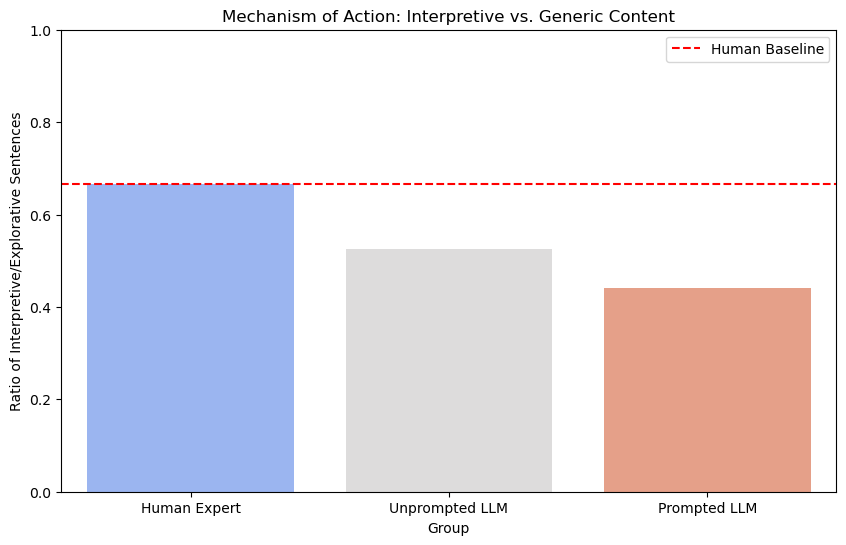

In [60]:
#Summary plot
results_df = pd.DataFrame({
    'Group': ['Human Expert', 'Unprompted LLM', 'Prompted LLM'],
    'Interpretive Ratio': [0.6659, 0.5244, 0.4420]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Group', y='Interpretive Ratio', palette='coolwarm')
plt.axhline(0.6659, color='red', linestyle='--', label='Human Baseline')
plt.title("Mechanism of Action: Interpretive vs. Generic Content")
plt.ylabel("Ratio of Interpretive/Explorative Sentences")
plt.ylim(0, 1)
plt.legend()
plt.savefig("genint_results.png", dpi=300)
plt.show()

In [62]:
#Prepare raw classifications
h_mech = htest_df[['mech']].dropna().rename(columns={'mech': 'Mechanism'})
h_mech['Group'] = 'Human'

un_mech = test_df[['mech_un']].dropna().rename(columns={'mech_un': 'Mechanism'})
un_mech['Group'] = 'Unprompted'

pr_mech = test_df[['mech_pr']].dropna().rename(columns={'mech_pr': 'Mechanism'})
pr_mech['Group'] = 'Prompted'

#Combine and Save
mech_raw_df = pd.concat([h_mech, un_mech, pr_mech], axis=0)
mech_raw_df.to_csv('mechanism_of_action_raw.csv', index=False)

## Statistical Test

In [138]:
#Create contingency table
mech_ct = pd.crosstab(mech_raw_df['Group'], mech_raw_df['Mechanism'])

#Run test
chi2, p, dof, ex = chi2_contingency(mech_ct)

print(f"\n--- Global Statistical Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
global_v = contingency.association(mech_ct, method="cramer")
print(f"Cramér's V: {global_v:.4f}")

#Define the pairs to compare
pairs = list(itertools.combinations(mech_ct.index, 2))
adj_alpha = 0.05 / len(pairs) #Bonferroni correction (0.0167)

print(f"--- Post-Hoc Pairwise Comparisons (Alpha Threshold: {adj_alpha:.4f}) ---")

for g1, g2 in pairs:
    #Isolate the two groups for comparison
    pair_table = mech_ct.loc[[g1, g2]]
    
    #Run Chi-Square on the pair
    chi2_pair, p_pair, _, _ = chi2_contingency(pair_table)
    #Calculate effect size for this specific pair
    v_pair = contingency.association(pair_table, method="cramer")
    
    status = "Significant" if p_pair < adj_alpha else "Not Significant"
    print(f"{g1} vs {g2}: p = {p_pair:.4e} ({status}) | Cramér's V = {v_pair:.4f}")


--- Global Statistical Results ---
Chi-Square Statistic: 155.7629
P-value: 1.5014e-34
Cramér's V: 0.1896
--- Post-Hoc Pairwise Comparisons (Alpha Threshold: 0.0167) ---
Human vs Prompted: p = 2.3769e-31 (Significant) | Cramér's V = 0.1983
Human vs Unprompted: p = 1.1276e-13 (Significant) | Cramér's V = 0.1267
Prompted vs Unprompted: p = 7.4168e-04 (Significant) | Cramér's V = 0.0824


# Intent Classification

Inspired by the framework of Hill (2009), two different granularities of intent classification are used to determine the ratio of listening vs. helping behaviors and measure whether the LLM moves beyond understanding to provide action-oriented support in a way that aligns with expert clinical practice.

In [68]:
#Initialize Classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)

#Define Hill-inspired Intent Labels
candidate_labels = ["Process-Oriented (Reflecting, Listening, Questioning)", 
                    "Action-Oriented (Guidance, Education, Advice)"]

def detect_helping_skill(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    
    result = classifier(text, candidate_labels, multi_label=False)
    #Return the top label
    return result['labels'][0]

#Apply to subsets
print("Analyzing Compassionate Empathy Intents...")

#AI Sample
test_llm = llm_subset_unique.copy()
test_llm['intent_un'] = test_llm['LLM_unprompted'].apply(detect_helping_skill)
test_llm['intent_pr'] = test_llm['LLM_prompted'].apply(detect_helping_skill)

#Human Sample
test_human = human_subset.copy()
test_human['intent'] = test_human['answerText'].apply(detect_helping_skill)

Analyzing Compassionate Empathy Intents...


In [70]:
#Create a long-form version for statistical tests
h_raw = test_human[['intent']].rename(columns={'intent': 'Intent'}).assign(Group='Human')
un_raw = test_llm[['intent_un']].rename(columns={'intent_un': 'Intent'}).assign(Group='Unprompted')
pr_raw = test_llm[['intent_pr']].rename(columns={'intent_pr': 'Intent'}).assign(Group='Prompted')

intent_raw_df = pd.concat([h_raw, un_raw, pr_raw])
intent_raw_df.to_csv('hill_intents_raw_results.csv', index=False)

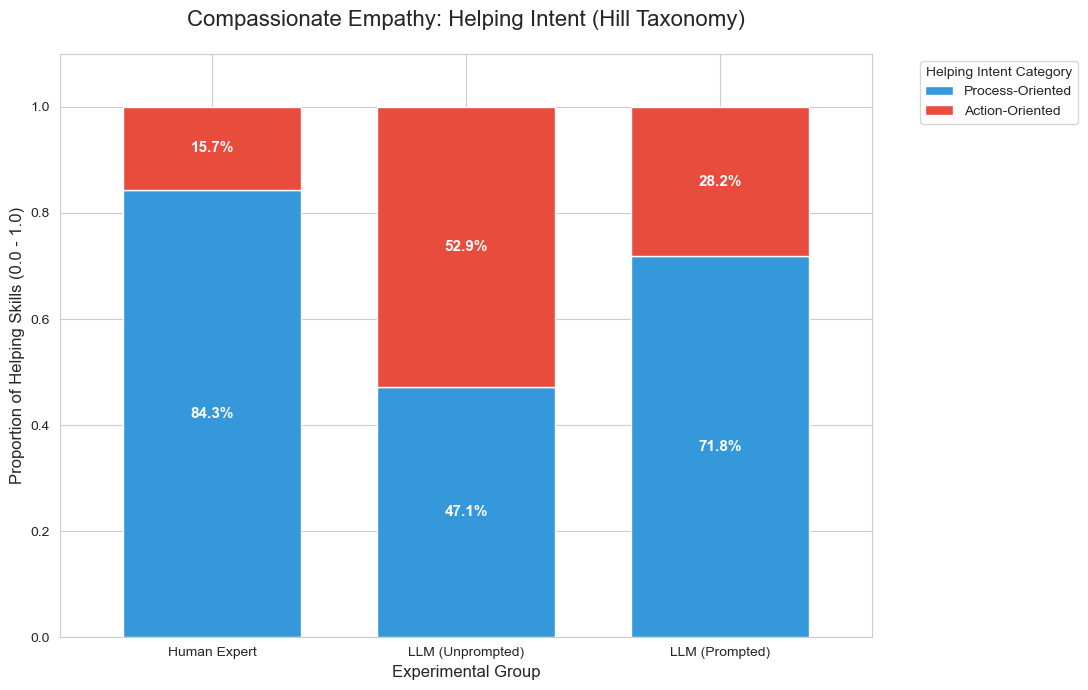

Visualization saved as 'compassionate_empathy_stacked_bar.png'


In [122]:
#Calculate proportions for each group
h_ratios = test_human['intent'].value_counts(normalize=True)
un_ratios = test_llm['intent_un'].value_counts(normalize=True)
pr_ratios = test_llm['intent_pr'].value_counts(normalize=True)

#Structure the data for plotting
labels = ["Process-Oriented (Reflecting, Listening, Questioning)", 
          "Action-Oriented (Guidance, Education, Advice)"]

plot_data = pd.DataFrame({
    'Process-Oriented': [h_ratios.get(labels[0], 0), un_ratios.get(labels[0], 0), pr_ratios.get(labels[0], 0)],
    'Action-Oriented': [h_ratios.get(labels[1], 0), un_ratios.get(labels[1], 0), pr_ratios.get(labels[1], 0)]
}, index=['Human Expert', 'LLM (Unprompted)', 'LLM (Prompted)'])

#Create a Stacked Bar Chart
ax = plot_data.plot(kind='bar', 
                    stacked=True, 
                    figsize=(11, 7), 
                    color=['#3498db', '#e74c3c'], # Blue for Process, Red for Action
                    width=0.7)

plt.title("Compassionate Empathy: Helping Intent (Hill Taxonomy)", fontsize=16, pad=20)
plt.ylabel("Proportion of Helping Skills (0.0 - 1.0)", fontsize=12)
plt.xlabel("Experimental Group", fontsize=12)
plt.xticks(rotation=0) 
plt.ylim(0, 1.1) 

#Add percentage labels on the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.05: #Only show label if the segment is large enough
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=11,
                fontweight='bold')

plt.legend(title="Helping Intent Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("compassionate_empathy_stacked_bar.png", dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved as 'compassionate_empathy_stacked_bar.png'")

## Statistical Test

In [136]:
#Create contingency table
ct_intent = pd.crosstab(intent_raw_df['Group'], intent_raw_df['Intent'])

chi2, p, dof, ex = chi2_contingency(ct_intent)

print(f"\n--- Global Statistical Results ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
global_v = contingency.association(ct_intent, method="cramer")
print(f"Cramér's V: {global_v:.4f}")

#Pairwise Comparisons
pairs = list(itertools.combinations(ct_intent.index, 2))
adj_alpha = 0.05 / len(pairs) #Bonferroni Correction

print(f"\n--- Post-Hoc Pairwise Comparisons (Alpha: {adj_alpha:.4f}) ---")
for g1, g2 in pairs:
    pair_table = ct_intent.loc[[g1, g2]]
    _, p_pair, _, _ = chi2_contingency(pair_table)

    #Calculate effect size for this specific pair
    v_pair = contingency.association(pair_table, method="cramer")
    
    status = "Significant" if p_pair < adj_alpha else "Not Significant"
    print(f"{g1} vs {g2}: p = {p_pair:.4e} ({status}) | Cramér's V = {v_pair:.4f}")



--- Global Statistical Results ---
Chi-Square Statistic: 475.8740
P-value: 4.6268e-104
Cramér's V: 0.3314

--- Post-Hoc Pairwise Comparisons (Alpha: 0.0167) ---
Human vs Prompted: p = 5.0577e-16 (Significant) | Cramér's V = 0.1385
Human vs Unprompted: p = 5.4468e-106 (Significant) | Cramér's V = 0.3719
Prompted vs Unprompted: p = 2.4977e-25 (Significant) | Cramér's V = 0.2516


# Sentence Level Classification

While the previous code classified the text based on the most dominant emotion in the reponse, sentence-level classification gives a better idea of how human therapists and llm therapists differ in terms of the distribution of process- and action-oriented intent within their responses.

In [82]:
#Initialize Classifier
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)

#Define Refined Labels (Including Neutral/Filler)
candidate_labels = [
    "Process-Oriented (Reflecting, Listening, Questioning)", 
    "Action-Oriented (Guidance, Education, Advice)",
    "Neutral (Salutations, Filler, or Meta-talk)"
]

#Hypothesis template improves Zero-Shot accuracy
hypo_template = "The intent of this therapeutic sentence is {}."

def detect_helping_skills_sentences(text):
    if pd.isna(text) or str(text).strip() == "":
        return []
    
    #Split the response into individual sentences
    sentences = sent_tokenize(str(text))
    
    #Classify all sentences in the response at once
    results = classifier(sentences, candidate_labels, hypothesis_template=hypo_template, multi_label=False)
    
    #Return a list of labels
    if isinstance(results, dict): #Handle case for single sentence
        return [results['labels'][0]]
    return [res['labels'][0] for res in results]

#Apply to Subsets
print("Working!")

#AI Sample
test_llm = llm_subset_unique.copy()
test_llm['intent_un_list'] = test_llm['LLM_unprompted'].apply(detect_helping_skills_sentences)
test_llm['intent_pr_list'] = test_llm['LLM_prompted'].apply(detect_helping_skills_sentences)

#Human Sample
test_human = human_subset.copy()
test_human['intent_list'] = test_human['answerText'].apply(detect_helping_skills_sentences)

Working!


In [84]:
h_sent = test_human[['intent_list']].explode('intent_list').dropna().rename(columns={'intent_list': 'Intent'}).assign(Group='Human')
un_sent = test_llm[['intent_un_list']].explode('intent_un_list').dropna().rename(columns={'intent_un_list': 'Intent'}).assign(Group='Unprompted')
pr_sent = test_llm[['intent_pr_list']].explode('intent_pr_list').dropna().rename(columns={'intent_pr_list': 'Intent'}).assign(Group='Prompted')

#Combine and Save
sent_raw_df = pd.concat([h_sent, un_sent, pr_sent])
sent_raw_df.to_csv('sentence_level_intents_raw.csv', index=False)
print("Sentence-level data saved to 'sentence_level_intents_raw.csv'")

Sentence-level data saved to 'sentence_level_intents_raw.csv'


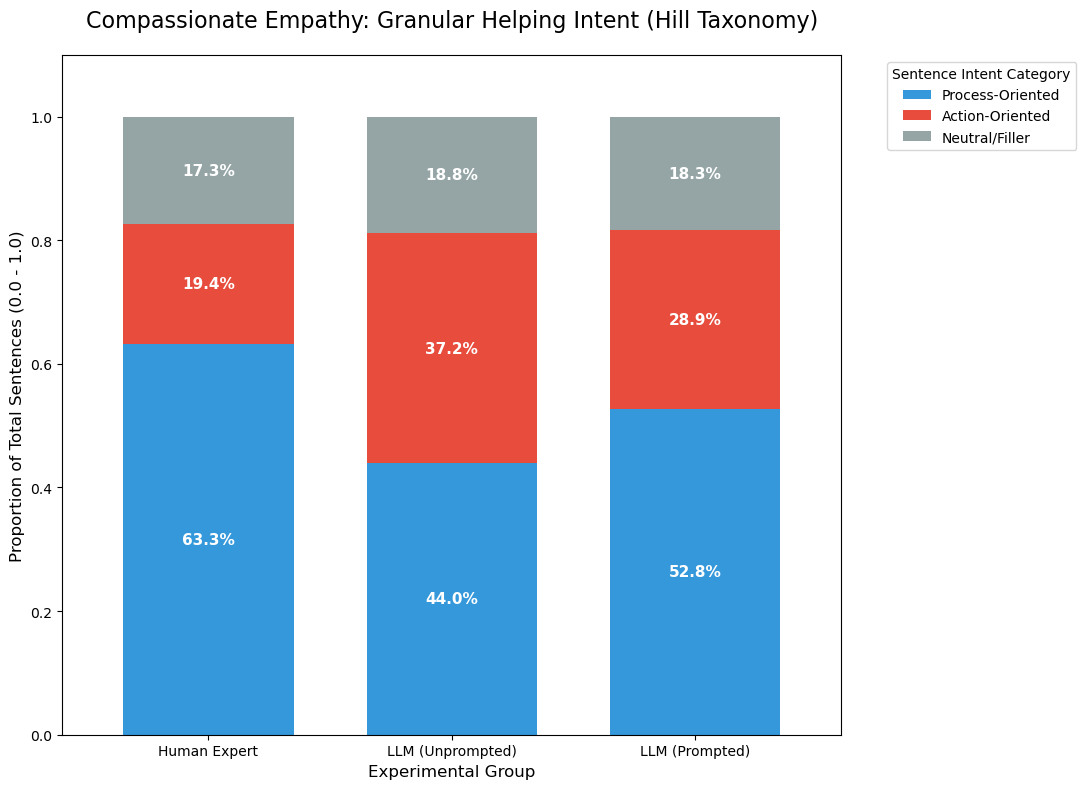

In [86]:
labels = [
    "Process-Oriented (Reflecting, Listening, Questioning)", 
    "Action-Oriented (Guidance, Education, Advice)",
    "Neutral (Salutations, Filler, or Meta-talk)"
]

def flatten_and_get_ratios(df, column):
    #Flatten the list into one big list of labels
    all_labels = [label for sublist in df[column].dropna() for label in sublist]
    #Calculate normalize (normalized value counts)
    return pd.Series(all_labels).value_counts(normalize=True)

#AI Sample
un_ratios_sent = flatten_and_get_ratios(test_llm, 'intent_un_list')
pr_ratios_sent = flatten_and_get_ratios(test_llm, 'intent_pr_list')

#Human Sample
h_ratios_sent = flatten_and_get_ratios(test_human, 'intent_list')

#Plotting
plot_data = pd.DataFrame({
    'Process-Oriented': [h_ratios_sent.get(labels[0], 0), un_ratios_sent.get(labels[0], 0), pr_ratios_sent.get(labels[0], 0)],
    'Action-Oriented': [h_ratios_sent.get(labels[1], 0), un_ratios_sent.get(labels[1], 0), pr_ratios_sent.get(labels[1], 0)],
    'Neutral/Filler': [h_ratios_sent.get(labels[2], 0), un_ratios_sent.get(labels[2], 0), pr_ratios_sent.get(labels[2], 0)]
}, index=['Human Expert', 'LLM (Unprompted)', 'LLM (Prompted)'])

ax = plot_data.plot(kind='bar', 
                    stacked=True, 
                    figsize=(11, 8), #Slightly taller to accommodate 3 segments
                    color=['#3498db', '#e74c3c', '#95a5a6'], # Blue (Process), Red (Action), Gray (Neutral)
                    width=0.7)

plt.title("Compassionate Empathy: Granular Helping Intent (Hill Taxonomy)", fontsize=16, pad=20)
plt.ylabel("Proportion of Total Sentences (0.0 - 1.0)", fontsize=12)
plt.xlabel("Experimental Group", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1) 

#Add Percentage Labels on the Bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.05: #Only show label if the segment is visible (greater than 5%)
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=11,
                fontweight='bold')

plt.legend(title="Sentence Intent Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("granular_compassion_stacked_bar.png", dpi=300, bbox_inches='tight')
plt.show()

## Statistical Test

In [134]:
#Create contingency table 
ct_sent = pd.crosstab(sent_raw_df['Group'], sent_raw_df['Intent'])

chi2, p, dof, ex = chi2_contingency(ct_sent)

print(f"\n--- Global Sentence-Level Statistics ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
global_v = contingency.association(ct_sent, method="cramer")
print(f"Cramér's V: {global_v:.4f}")

#Pairwise Comparisons
pairs = list(itertools.combinations(ct_sent.index, 2))
adj_alpha = 0.05 / len(pairs) #Bonferroni Correction

print(f"\n--- Post-Hoc Pairwise Comparisons (Alpha: {adj_alpha:.4f}) ---")
for g1, g2 in pairs:
    pair_table = ct_sent.loc[[g1, g2]]
    _, p_pair, _, _ = chi2_contingency(pair_table)
    # Calculate effect size for this specific pair
    v_pair = contingency.association(pair_table, method="cramer")
    status = "Significant" if p_pair < adj_alpha else "Not Significant"
    print(f"{g1} vs {g2}: p = {p_pair:.4e} ({status}) | Cramér's V = {v_pair:.4f}")



--- Global Sentence-Level Statistics ---
Chi-Square Statistic: 1487.0810
P-value: 0.0000e+00
Cramér's V: 0.1316

--- Post-Hoc Pairwise Comparisons (Alpha: 0.0167) ---
Human vs Prompted: p = 4.1987e-88 (Significant) | Cramér's V = 0.1143
Human vs Unprompted: p = 0.0000e+00 (Significant) | Cramér's V = 0.2104
Prompted vs Unprompted: p = 3.1381e-44 (Significant) | Cramér's V = 0.0954


# Granular Full-Text-Level Classification

Using more granular labels, resembling four key elements of therapeutic dialogue, insight could be gained into the composition of the therapeutic responses.

In [90]:
#Updated labels for a more in-depth look
granular_labels = ["Reflection", "Validation", "Direct Guidance", "Psychoeducation"]

def detect_granular_skills(text):
    if pd.isna(text) or str(text).strip() == "":
        return None
    #Model picks the most dominant intent
    result = classifier(text, granular_labels, multi_label=False)
    return result['labels'][0]

print("Running Granular Compassion Analysis...")
test_llm['granular_un'] = test_llm['LLM_unprompted'].apply(detect_granular_skills)
test_llm['granular_pr'] = test_llm['LLM_prompted'].apply(detect_granular_skills)
test_human['granular_h'] = test_human['answerText'].apply(detect_granular_skills)

Running Granular Compassion Analysis...


In [92]:
#Prepare raw labels
h_gran_raw = test_human[['granular_h']].dropna().rename(columns={'granular_h': 'Skill'}).assign(Group='Human')
un_gran_raw = test_llm[['granular_un']].dropna().rename(columns={'granular_un': 'Skill'}).assign(Group='Unprompted')
pr_gran_raw = test_llm[['granular_pr']].dropna().rename(columns={'granular_pr': 'Skill'}).assign(Group='Prompted')

#Combine and Save
granular_raw_df = pd.concat([h_gran_raw, un_gran_raw, pr_gran_raw])
granular_raw_df.to_csv('granular_clinical_skills_raw.csv', index=False)
print("Granular results saved to 'granular_clinical_skills_raw.csv'")

Granular results saved to 'granular_clinical_skills_raw.csv'


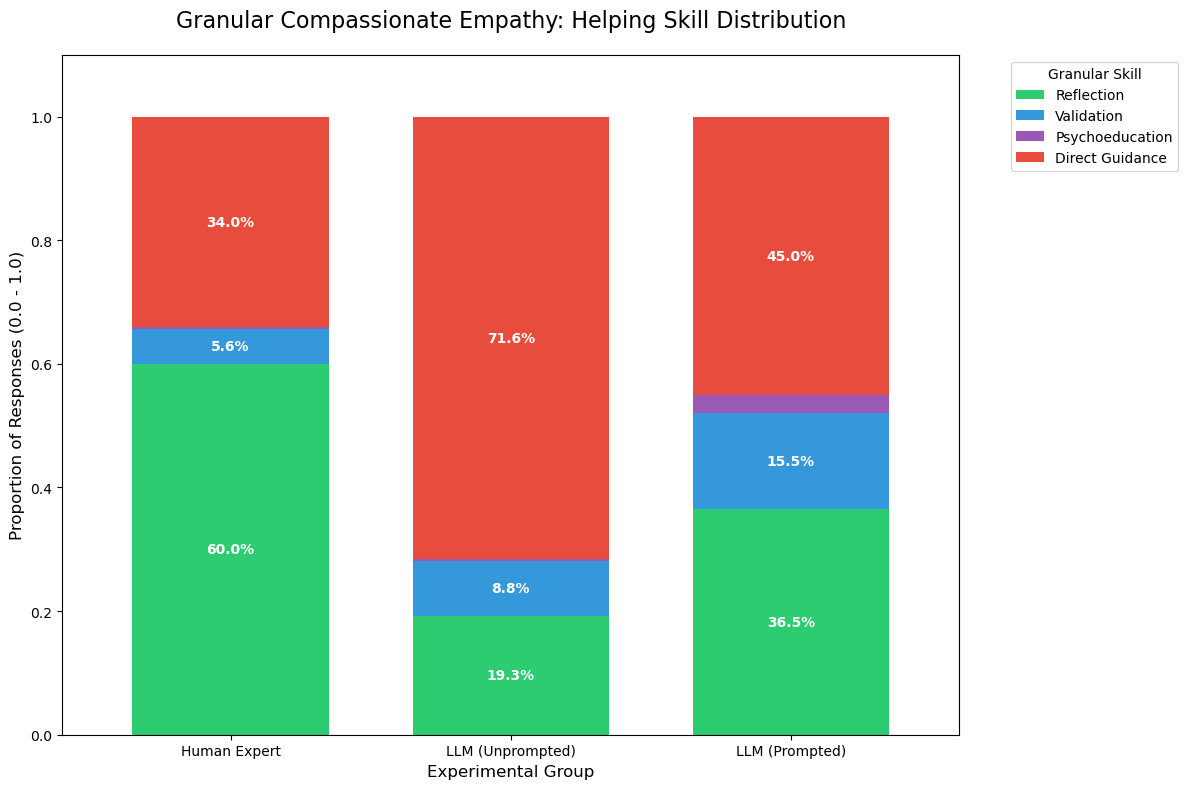

In [94]:
#Calculate proportions for the 4 granular categories
h_granular = test_human['granular_h'].value_counts(normalize=True)
un_granular = test_llm['granular_un'].value_counts(normalize=True)
pr_granular = test_llm['granular_pr'].value_counts(normalize=True)

#Define labels
granular_labels = ["Reflection", "Validation", "Psychoeducation", "Direct Guidance"]

#Create the plotting dataframe
plot_data_granular = pd.DataFrame({
    'Reflection': [h_granular.get('Reflection', 0), un_granular.get('Reflection', 0), pr_granular.get('Reflection', 0)],
    'Validation': [h_granular.get('Validation', 0), un_granular.get('Validation', 0), pr_granular.get('Validation', 0)],
    'Psychoeducation': [h_granular.get('Psychoeducation', 0), un_granular.get('Psychoeducation', 0), pr_granular.get('Psychoeducation', 0)],
    'Direct Guidance': [h_granular.get('Direct Guidance', 0), un_granular.get('Direct Guidance', 0), pr_granular.get('Direct Guidance', 0)]
}, index=['Human Expert', 'LLM (Unprompted)', 'LLM (Prompted)'])

#Create the Stacked Bar Chart
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c'] 
ax = plot_data_granular.plot(kind='bar', 
                             stacked=True, 
                             figsize=(12, 8), 
                             color=colors, 
                             width=0.7)

plt.title("Granular Compassionate Empathy: Helping Skill Distribution", fontsize=16, pad=20)
plt.ylabel("Proportion of Responses (0.0 - 1.0)", fontsize=12)
plt.xlabel("Experimental Group", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)

#Add percentage labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.04: #Only label segments larger than 4%
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                fontsize=10,
                fontweight='bold')

plt.legend(title="Granular Skill", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("granular_compassion_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

## Statistical Test

In [184]:
#Contingency Table
ct_gran = pd.crosstab(granular_raw_df['Group'], granular_raw_df['Skill'])

chi2, p, dof, ex = chi2_contingency(ct_gran)

print(f"\n--- Global Granular Skills Statistics ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
global_v = contingency.association(ct_gran, method="cramer")
print(f"Cramér's V: {global_v:.4f}")

#Pairwise Comparisons
pairs = list(itertools.combinations(ct_gran.index, 2))
adj_alpha = 0.05 / len(pairs) 

print(f"\n--- Post-Hoc Pairwise Comparisons (Alpha: {adj_alpha:.4f}) ---")

for g1, g2 in pairs:
    pair_table = ct_gran.loc[[g1, g2]]
    _, p_pair, _, _ = chi2_contingency(pair_table)
    
    #Calculate effect size for this specific pair
    v_pair = contingency.association(pair_table, method="cramer")
    
    status = "Significant" if p_pair < adj_alpha else "Not Significant"
    print(f"{g1} vs {g2}: p = {p_pair:.4e} ({status}) | Cramér's V = {v_pair:.4f}")


--- Global Granular Skills Statistics ---
Chi-Square Statistic: 594.9380
P-value: 2.8815e-125
Cramér's V: 0.2620

--- Post-Hoc Pairwise Comparisons (Alpha: 0.0167) ---
Human vs Prompted: p = 4.0496e-45 (Significant) | Cramér's V = 0.2455
Human vs Unprompted: p = 1.6323e-94 (Significant) | Cramér's V = 0.3550
Prompted vs Unprompted: p = 2.3959e-28 (Significant) | Cramér's V = 0.2763


# More Specific Sentence-Level Classification

In [98]:
#Initialize Classifier
#Using bart-large-mnli is the right choice for these clinical labels
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)

#Define the Labels & Template
candidate_labels = ["Reflection", "Validation", "Direct Guidance", "Psychoeducation", "Neutral"]

#Using a focused template helps the NLI model avoid "halo effects"
hypo_template = "The intent of this statement is {}."

def detect_miti_density(text):
    if pd.isna(text) or str(text).strip() == "":
        return []
    
    #Tokenize into sentences
    sentences = sent_tokenize(str(text))
    
    #Batch process all sentences
    results = classifier(sentences, candidate_labels, hypothesis_template=hypo_template, multi_label=False)
    
    #Return list of top labels for each sentence
    if isinstance(results, dict): 
        return [results['labels'][0]]
    return [res['labels'][0] for res in results]

#AI Samples
test_llm = llm_subset_unique.copy()
test_llm['sent_labels_un'] = test_llm['LLM_unprompted'].apply(detect_miti_density)
test_llm['sent_labels_pr'] = test_llm['LLM_prompted'].apply(detect_miti_density)

#Human Sample
test_human = human_subset.copy()
test_human['sent_labels_h'] = test_human['answerText'].apply(detect_miti_density)

In [100]:
#Flatten the lists of sentence labels into individual rows
h_gran_sent = test_human[['sent_labels_h']].explode('sent_labels_h').dropna().rename(columns={'sent_labels_h': 'Skill'}).assign(Group='Human')
un_gran_sent = test_llm[['sent_labels_un']].explode('sent_labels_un').dropna().rename(columns={'sent_labels_un': 'Skill'}).assign(Group='Unprompted')
pr_gran_sent = test_llm[['sent_labels_pr']].explode('sent_labels_pr').dropna().rename(columns={'sent_labels_pr': 'Skill'}).assign(Group='Prompted')

# Combine and Save
gran_sent_raw_df = pd.concat([h_gran_sent, un_gran_sent, pr_gran_sent])
gran_sent_raw_df.to_csv('sentence_granular_skills_raw.csv', index=False)
print("Sentence-level granular data saved to 'sentence_granular_skills_raw.csv'")

Sentence-level granular data saved to 'sentence_granular_skills_raw.csv'


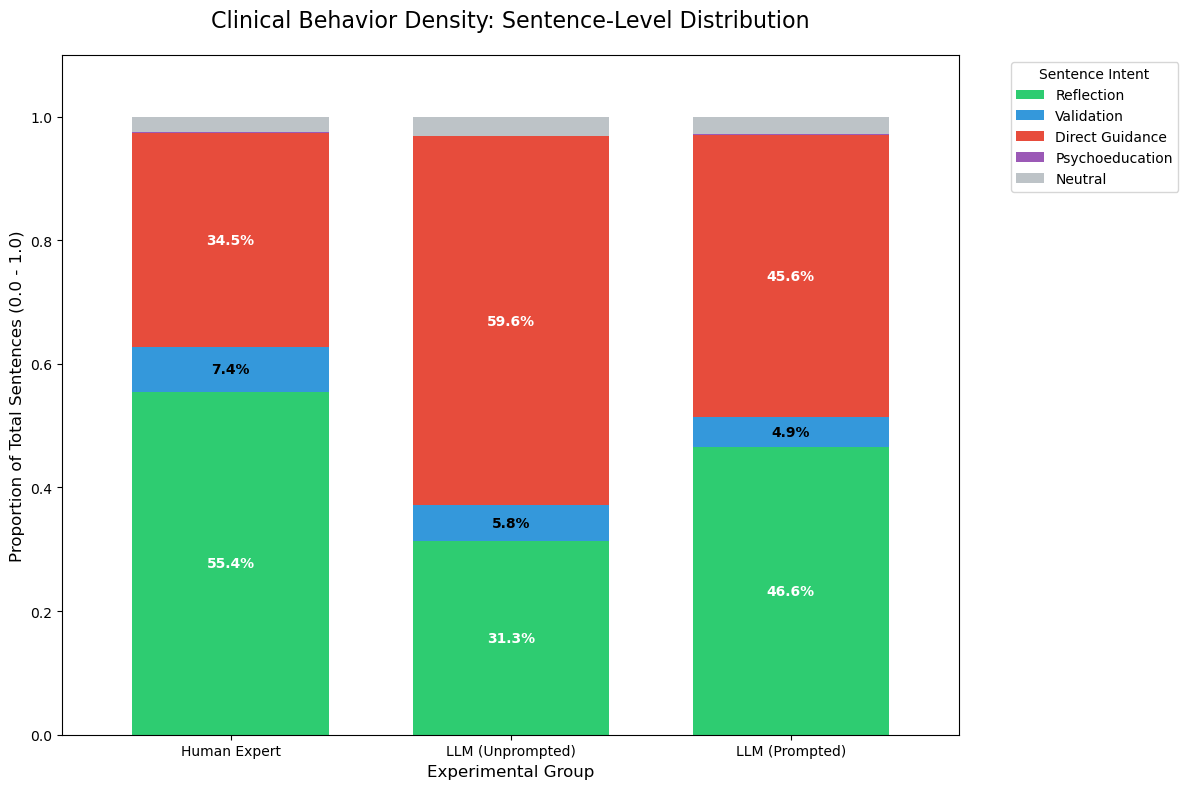

In [102]:
labels = ["Reflection", "Validation", "Direct Guidance", "Psychoeducation", "Neutral"]

def get_sentence_level_ratios(df, column):
    #Takes every list of labels in the column and turn it into one long list
    all_sentences = [label for sublist in df[column].dropna() for label in sublist]
    #Calculate the percentage each label occupies in the whole group
    return pd.Series(all_sentences).value_counts(normalize=True)

#Calculate proportions for each group
h_ratios = get_sentence_level_ratios(test_human, 'sent_labels_h')
un_ratios = get_sentence_level_ratios(test_llm, 'sent_labels_un')
pr_ratios = get_sentence_level_ratios(test_llm, 'sent_labels_pr')

#Plotting
plot_data_sentence = pd.DataFrame({
    'Reflection': [h_ratios.get(labels[0], 0), un_ratios.get(labels[0], 0), pr_ratios.get(labels[0], 0)],
    'Validation': [h_ratios.get(labels[1], 0), un_ratios.get(labels[1], 0), pr_ratios.get(labels[1], 0)],
    'Direct Guidance': [h_ratios.get(labels[2], 0), un_ratios.get(labels[2], 0), pr_ratios.get(labels[2], 0)],
    'Psychoeducation': [h_ratios.get(labels[3], 0), un_ratios.get(labels[3], 0), pr_ratios.get(labels[3], 0)],
    'Neutral': [h_ratios.get(labels[4], 0), un_ratios.get(labels[4], 0), pr_ratios.get(labels[4], 0)]
}, index=['Human Expert', 'LLM (Unprompted)', 'LLM (Prompted)'])

colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#bdc3c7'] 
ax = plot_data_sentence.plot(kind='bar', 
                             stacked=True, 
                             figsize=(12, 8), 
                             color=colors, 
                             width=0.7)

plt.title("Clinical Behavior Density: Sentence-Level Distribution", fontsize=16, pad=20)
plt.ylabel("Proportion of Total Sentences (0.0 - 1.0)", fontsize=12)
plt.xlabel("Experimental Group", fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 1.1)

#Add percentage labels
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0.04: #Only label segments larger than 4%
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1%}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white' if height > 0.1 else 'black', # Better contrast for small slices
                fontsize=10,
                fontweight='bold')

plt.legend(title="Sentence Intent", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("sentence_level_clinical_density.png", dpi=300, bbox_inches='tight')
plt.show()

## Statistical Test

In [124]:
#Contingency Table
ct_gran_sent = pd.crosstab(gran_sent_raw_df['Group'], gran_sent_raw_df['Skill'])

chi2, p, dof, ex = chi2_contingency(ct_gran_sent)

print(f"\n--- Global Sentence-Level Granular Statistics ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4e}")
global_v = contingency.association(ct_gran_sent, method="cramer")
print(f"Cramér's V: {global_v:.4f}")

#Pairwise Comparison
pairs = list(itertools.combinations(ct_gran_sent.index, 2))
adj_alpha = 0.05 / len(pairs) 

print(f"\n--- Post-Hoc Pairwise Comparisons (Alpha: {adj_alpha:.4f}) ---")
for g1, g2 in pairs:
    pair_table = ct_gran_sent.loc[[g1, g2]]
    _, p_pair, _, _ = chi2_contingency(pair_table)
    
    #Calculate effect size for this specific pair
    v_pair = contingency.association(pair_table, method="cramer")
    
    status = "Significant" if p_pair < adj_alpha else "Not Significant"
    print(f"{g1} vs {g2}: p = {p_pair:.4e} ({status}) | Cramér's V = {v_pair:.4f}")



--- Global Sentence-Level Granular Statistics ---
Chi-Square Statistic: 2140.1230
P-value: 0.0000e+00
Cramér's V: 0.1579

--- Post-Hoc Pairwise Comparisons (Alpha: 0.0167) ---
Human vs Prompted: p = 1.3706e-81 (Significant) | Cramér's V = 0.1115
Human vs Unprompted: p = 0.0000e+00 (Significant) | Cramér's V = 0.2522
Prompted vs Unprompted: p = 3.3623e-116 (Significant) | Cramér's V = 0.1571
